步骤0: 数据获取与预处理
获取中国银行(601988.SH)从20221220到20251219的数据...
成功获取727条数据
数据时间范围: 2022-12-20 00:00:00 到 2025-12-18 00:00:00
数据样例:
            close
trade_date       
2022-12-20   2.63
2022-12-21   2.63
2022-12-22   2.64
2022-12-23   2.63
2022-12-26   2.62


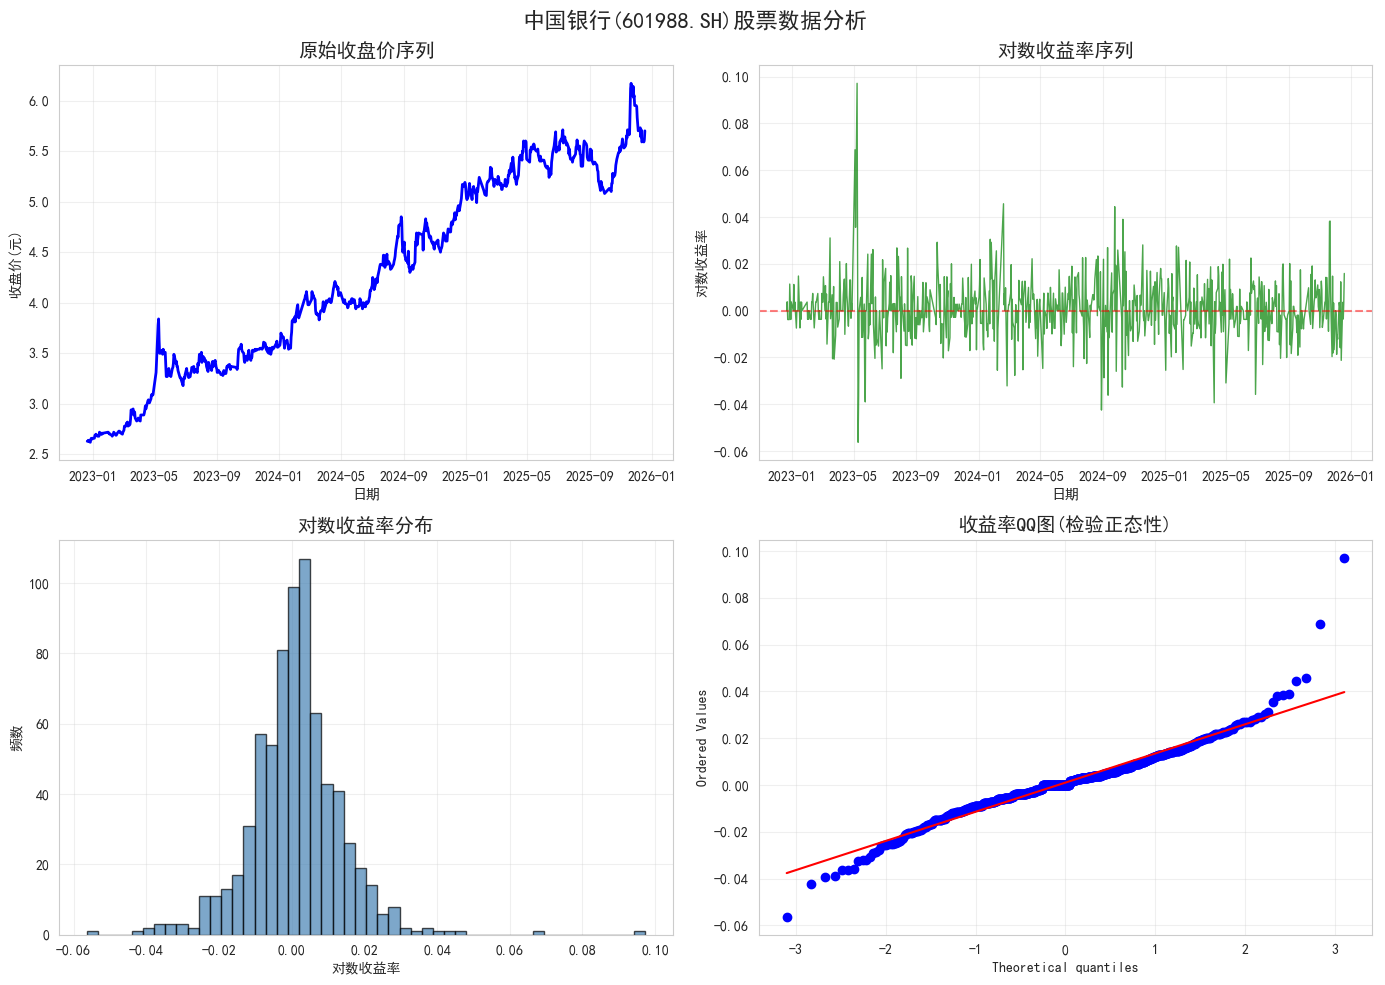

In [28]:
'''
ARIMA模型预测股票市场例子。
'''
# ========== 导入库 ==========
import tushare as ts
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.plotting import register_matplotlib_converters
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 统计建模相关库
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats

# 设置中文字体和图表样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
#sns.set_style("whitegrid")

register_matplotlib_converters()

# ========== 数据加载与预处理 ==========
print("步骤0: 数据获取与预处理")
print("=" * 60)

# 设置Tushare Token（请替换为您自己的token）
ts.set_token('')
pro = ts.pro_api()

# 设置时间范围
end_date = datetime.now().strftime('%Y%m%d')
start_date = (datetime.now() - timedelta(days=3*365)).strftime('%Y%m%d')

print(f"获取中国银行(601988.SH)从{start_date}到{end_date}的数据...")

# 获取股票数据
try:
    raw_df = ts.pro_bar(
        ts_code='601988.SH',   # 000001.SZ 平安银行，601988.SH 中国银行
        asset='E',
        start_date=start_date,
        end_date=end_date,
        adj='qfq'
    )
    
    if raw_df.empty:
        raise ValueError("获取的数据为空，请检查token和股票代码")
    
    print(f"成功获取{len(raw_df)}条数据")
    
except Exception as e:
    print(f"数据获取失败: {e}")


# 数据清洗和准备
raw_df['trade_date'] = pd.to_datetime(raw_df['trade_date'], format='%Y%m%d')
df = raw_df.sort_values('trade_date').reset_index(drop=True)

# 创建时间序列索引
df.set_index('trade_date', inplace=True)

print(f"数据时间范围: {df.index.min()} 到 {df.index.max()}")
print(f"数据样例:")
print(df[['close']].head())

# 可视化原始价格序列
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('中国银行(601988.SH)股票数据分析', fontsize=16, fontweight='bold')

# 原始价格序列
axes[0, 0].plot(df.index, df['close'], linewidth=2, color='blue')
axes[0, 0].set_title('原始收盘价序列', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('日期')
axes[0, 0].set_ylabel('收盘价(元)')
axes[0, 0].grid(True, alpha=0.3)

# 计算对数收益率（金融分析常用）
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['simple_return'] = df['close'].pct_change()

# 对数收益率序列
axes[0, 1].plot(df.index[1:], df['log_return'].dropna(), linewidth=1, color='green', alpha=0.7)
axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 1].set_title('对数收益率序列', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('日期')
axes[0, 1].set_ylabel('对数收益率')
axes[0, 1].grid(True, alpha=0.3)

# 收益率的直方图
axes[1, 0].hist(df['log_return'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('对数收益率分布', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('对数收益率')
axes[1, 0].set_ylabel('频数')
axes[1, 0].grid(True, alpha=0.3)

# QQ图检验正态性
stats.probplot(df['log_return'].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('收益率QQ图(检验正态性)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



步骤1: 平稳性检验与差分 (确定参数d)

1.1 检验原始价格序列的平稳性:
ADF检验 - 原始收盘价:
  ADF统计量: -1.006370
  p-value: 0.750934
  临界值:
    1%: -3.439427
    5%: -2.865546
    10%: -2.568903
  结论: p值(0.750934) ≥ 0.05，序列是非平稳的

1.2 检验对数收益率序列的平稳性:
ADF检验 - 对数收益率:
  ADF统计量: -16.374919
  p-value: 0.000000
  临界值:
    1%: -3.439427
    5%: -2.865546
    10%: -2.568903
  结论: p值(0.000000) < 0.05，序列是平稳的

对数收益率序列已平稳，差分阶数 d = 0


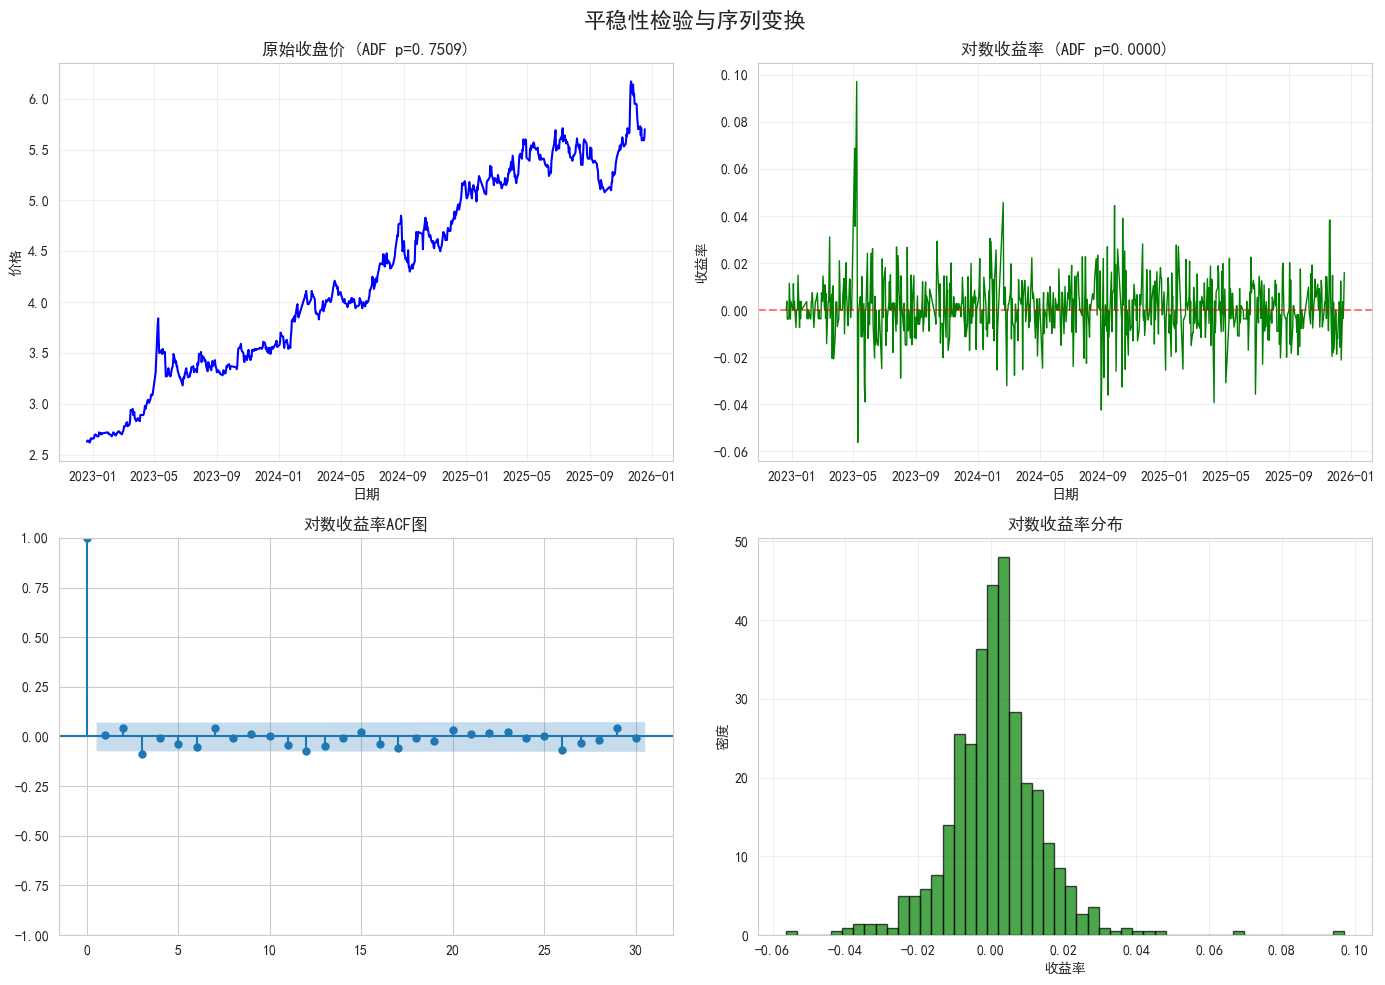


★ 步骤1总结: 确定差分阶数 d = 0


In [29]:
'''
ARIMA模型预测股票市场例子。
'''
# ========== 步骤1: 平稳性检验与差分 (确定d) ==========
print("\n" + "="*60)
print("步骤1: 平稳性检验与差分 (确定参数d)")
print("="*60)

def adf_test(series, title=''):
    """
    执行ADF单位根检验，判断序列是否平稳
    """
    result = adfuller(series.dropna())
    print(f'ADF检验 - {title}:')
    print(f'  ADF统计量: {result[0]:.6f}')
    print(f'  p-value: {result[1]:.6f}')
    print(f'  临界值:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.6f}')
    
    if result[1] < 0.05:
        print(f'  结论: p值({result[1]:.6f}) < 0.05，序列是平稳的')
        return True, result[1]
    else:
        print(f'  结论: p值({result[1]:.6f}) ≥ 0.05，序列是非平稳的')
        return False, result[1]

# 测试原始价格序列的平稳性
print("\n1.1 检验原始价格序列的平稳性:")
price_series = df['close']
is_stationary_price, p_value_price = adf_test(price_series, '原始收盘价')

# 测试对数收益率序列的平稳性
print("\n1.2 检验对数收益率序列的平稳性:")
return_series = df['log_return'].dropna()
is_stationary_return, p_value_return = adf_test(return_series, '对数收益率')

# 如果对数收益率不平稳，进行差分
d = 0  # 差分阶数初始值
current_series = return_series.copy()

if not is_stationary_return:
    print("\n1.3 对数收益率序列不平稳，尝试一阶差分...")
    diff_series = current_series.diff().dropna()
    is_stationary_diff, p_value_diff = adf_test(diff_series, '一阶差分后序列')
    
    if is_stationary_diff:
        d = 1
        current_series = diff_series
        print(f"确定差分阶数 d = {d}")
    else:
        print("一阶差分后仍不平稳，可能需要更高阶差分或数据转换")
else:
    print(f"\n对数收益率序列已平稳，差分阶数 d = {d}")

# 可视化平稳性检验结果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('平稳性检验与序列变换', fontsize=16, fontweight='bold')

# 原始价格序列
axes[0, 0].plot(price_series.index, price_series.values, linewidth=1.5, color='blue')
axes[0, 0].set_title(f'原始收盘价 (ADF p={p_value_price:.4f})', fontsize=12)
axes[0, 0].set_xlabel('日期')
axes[0, 0].set_ylabel('价格')
axes[0, 0].grid(True, alpha=0.3)

# 对数收益率序列
axes[0, 1].plot(return_series.index, return_series.values, linewidth=1, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 1].set_title(f'对数收益率 (ADF p={p_value_return:.4f})', fontsize=12)
axes[0, 1].set_xlabel('日期')
axes[0, 1].set_ylabel('收益率')
axes[0, 1].grid(True, alpha=0.3)

# 如果进行了差分，显示差分后的序列
if d > 0:
    axes[1, 0].plot(diff_series.index, diff_series.values, linewidth=1, color='purple')
    axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].set_title(f'一阶差分后序列 (ADF p={p_value_diff:.4f})', fontsize=12)
    axes[1, 0].set_xlabel('日期')
    axes[1, 0].set_ylabel('差分值')
    axes[1, 0].grid(True, alpha=0.3)
else:
    # 显示收益率的自相关图
    plot_acf(current_series, lags=30, ax=axes[1, 0], title='对数收益率ACF图')
    axes[1, 0].set_title('对数收益率ACF图', fontsize=12)

# 收益率的分布变化
if d > 0:
    axes[1, 1].hist(diff_series.values, bins=50, color='purple', edgecolor='black', alpha=0.7, density=True)
    axes[1, 1].set_title('一阶差分后序列分布', fontsize=12)
    axes[1, 1].set_xlabel('差分值')
    axes[1, 1].set_ylabel('密度')
else:
    axes[1, 1].hist(current_series.values, bins=50, color='green', edgecolor='black', alpha=0.7, density=True)
    axes[1, 1].set_title('对数收益率分布', fontsize=12)
    axes[1, 1].set_xlabel('收益率')
    axes[1, 1].set_ylabel('密度')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n★ 步骤1总结: 确定差分阶数 d = {d}")



步骤2: 模型识别 (确定参数p和q)
使用平稳序列进行模型识别，序列长度: 726
观察ACF和PACF图以确定p和q的候选值...


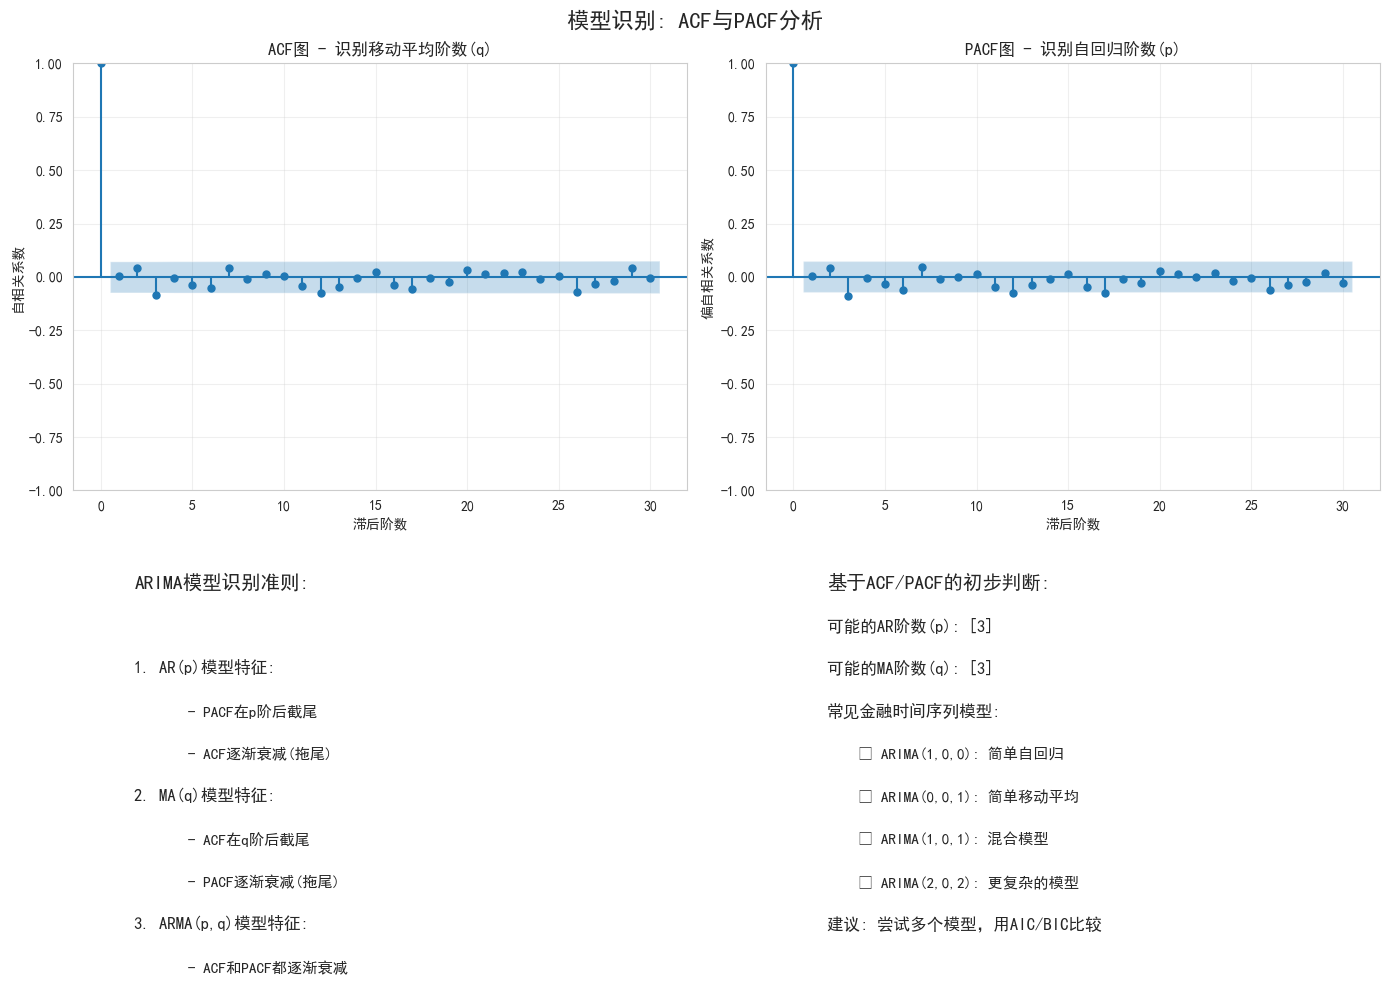


2.1 使用AIC/BIC准则选择最佳(p,q)组合...
测试的p值: [0, 1, 2, 3]
测试的q值: [0, 1, 2, 3]
将测试以下(p,q)组合: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
训练集大小: 580，测试集大小: 146
  ARIMA(0,0,0): AIC=-3369.68, BIC=-3360.95, RMSE=0.011121
  ARIMA(0,0,1): AIC=-3367.70, BIC=-3354.61, RMSE=0.011121
  ARIMA(0,0,2): AIC=-3366.02, BIC=-3348.57, RMSE=0.011121
  ARIMA(1,0,0): AIC=-3367.70, BIC=-3354.61, RMSE=0.011122
  ARIMA(1,0,1): AIC=-3365.68, BIC=-3348.23, RMSE=0.011122
  ARIMA(1,0,2): AIC=-3364.39, BIC=-3342.57, RMSE=0.011121
  ARIMA(2,0,0): AIC=-3365.99, BIC=-3348.54, RMSE=0.011121
  ARIMA(2,0,1): AIC=-3364.00, BIC=-3342.19, RMSE=0.011121
  ARIMA(2,0,2): AIC=-3362.50, BIC=-3336.32, RMSE=0.011121

★ 步骤2总结: 基于AIC准则，选择最佳模型 ARIMA(0,0,0)
  最佳模型AIC: -3369.68
  最佳模型BIC: -3360.95
  测试集RMSE: 0.011121


In [30]:
'''
ARIMA模型预测股票市场例子。
'''
# ========== 步骤2: 模型识别 (确定p和q) ==========
print("\n" + "="*60)
print("步骤2: 模型识别 (确定参数p和q)")
print("="*60)

# 准备平稳序列（用于模型识别）
working_series = current_series

print(f"使用平稳序列进行模型识别，序列长度: {len(working_series)}")
print("观察ACF和PACF图以确定p和q的候选值...")

# 绘制ACF和PACF图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('模型识别: ACF与PACF分析', fontsize=16, fontweight='bold')

# ACF图（自相关函数）
plot_acf(working_series, lags=30, ax=axes[0, 0], title='ACF图 (确定MA阶数q)')
axes[0, 0].set_title('ACF图 - 识别移动平均阶数(q)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('滞后阶数')
axes[0, 0].set_ylabel('自相关系数')
axes[0, 0].grid(True, alpha=0.3)

# PACF图（偏自相关函数）
plot_pacf(working_series, lags=30, ax=axes[0, 1], title='PACF图 (确定AR阶数p)')
axes[0, 1].set_title('PACF图 - 识别自回归阶数(p)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('滞后阶数')
axes[0, 1].set_ylabel('偏自相关系数')
axes[0, 1].grid(True, alpha=0.3)

# 提供判断准则
axes[1, 0].axis('off')
axes[1, 0].text(0.1, 0.9, 'ARIMA模型识别准则:', fontsize=14, fontweight='bold')
axes[1, 0].text(0.1, 0.7, '1. AR(p)模型特征:', fontsize=12, fontweight='bold')
axes[1, 0].text(0.15, 0.6, '   - PACF在p阶后截尾', fontsize=11)
axes[1, 0].text(0.15, 0.5, '   - ACF逐渐衰减(拖尾)', fontsize=11)
axes[1, 0].text(0.1, 0.4, '2. MA(q)模型特征:', fontsize=12, fontweight='bold')
axes[1, 0].text(0.15, 0.3, '   - ACF在q阶后截尾', fontsize=11)
axes[1, 0].text(0.15, 0.2, '   - PACF逐渐衰减(拖尾)', fontsize=11)
axes[1, 0].text(0.1, 0.1, '3. ARMA(p,q)模型特征:', fontsize=12, fontweight='bold')
axes[1, 0].text(0.15, 0.0, '   - ACF和PACF都逐渐衰减', fontsize=11)

# 分析ACF/PACF特征
acf_vals, confint = acf(working_series, nlags=30, fft=True, alpha=0.05)
pacf_vals, confint_pacf = pacf(working_series, nlags=30, alpha=0.05)

# 找出截尾点（相关性在置信区间内）
sig_level = 1.96 / np.sqrt(len(working_series))

# 寻找可能的p值（PACF截尾）
p_candidates = []
for i in range(1, min(8, len(pacf_vals))):  # 检查前8阶
    if abs(pacf_vals[i]) > sig_level and (i == len(pacf_vals)-1 or abs(pacf_vals[i+1]) < sig_level):
        p_candidates.append(i)

# 寻找可能的q值（ACF截尾）
q_candidates = []
for i in range(1, min(8, len(acf_vals))):  # 检查前8阶
    if abs(acf_vals[i]) > sig_level and (i == len(acf_vals)-1 or abs(acf_vals[i+1]) < sig_level):
        q_candidates.append(i)

if not p_candidates:
    # 如果没有明显截尾，尝试常见的低阶值
    p_candidates = [0, 1, 2]
if not q_candidates:
    q_candidates = [0, 1, 2]

axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.9, '基于ACF/PACF的初步判断:', fontsize=14, fontweight='bold')
axes[1, 1].text(0.1, 0.8, f'可能的AR阶数(p): {p_candidates}', fontsize=12)
axes[1, 1].text(0.1, 0.7, f'可能的MA阶数(q): {q_candidates}', fontsize=12)
axes[1, 1].text(0.1, 0.6, '常见金融时间序列模型:', fontsize=12, fontweight='bold')
axes[1, 1].text(0.15, 0.5, '• ARIMA(1,0,0): 简单自回归', fontsize=11)
axes[1, 1].text(0.15, 0.4, '• ARIMA(0,0,1): 简单移动平均', fontsize=11)
axes[1, 1].text(0.15, 0.3, '• ARIMA(1,0,1): 混合模型', fontsize=11)
axes[1, 1].text(0.15, 0.2, '• ARIMA(2,0,2): 更复杂的模型', fontsize=11)
axes[1, 1].text(0.1, 0.1, '建议: 尝试多个模型，用AIC/BIC比较', fontsize=12)

plt.tight_layout()
plt.show()

# 尝试多个模型组合，使用AIC/BIC准则选择最佳模型
print("\n2.1 使用AIC/BIC准则选择最佳(p,q)组合...")
candidate_models = []
if len(p_candidates) > 3:
    p_candidates = p_candidates[:3]
if len(q_candidates) > 3:
    q_candidates = q_candidates[:3]

# 添加一些常见组合
common_combinations = [(0,0), (1,0), (0,1), (1,1), (2,0), (0,2), (2,1), (1,2), (2,2)]
for p, q in common_combinations:
    if p not in p_candidates:
        p_candidates.append(p)
    if q not in q_candidates:
        q_candidates.append(q)

# 去重
p_candidates = sorted(list(set(p_candidates)))
q_candidates = sorted(list(set(q_candidates)))

print(f"测试的p值: {p_candidates}")
print(f"测试的q值: {q_candidates}")

# 为了避免计算时间过长，限制组合数量
max_combinations = 9
tested_combinations = []

for p in p_candidates[:3]:  # 只测试前3个p值
    for q in q_candidates[:3]:  # 只测试前3个q值
        if len(tested_combinations) >= max_combinations:
            break
        tested_combinations.append((p, q))

print(f"将测试以下(p,q)组合: {tested_combinations}")

# 分割数据为训练集和测试集
train_size = int(len(working_series) * 0.8)
train_series = working_series[:train_size]
test_series = working_series[train_size:]

print(f"训练集大小: {len(train_series)}，测试集大小: {len(test_series)}")

# 存储模型结果
results = []

for p, q in tested_combinations:
    try:
        # 使用训练集拟合模型
        model = ARIMA(train_series, order=(p, 0, q))  # 注意：这里d=0，因为我们已经在步骤1中进行了差分
        model_fit = model.fit()
        
        # 计算测试集预测
        forecast = model_fit.forecast(steps=len(test_series))
        
        # 计算均方根误差(RMSE)
        rmse = np.sqrt(np.mean((test_series.values - forecast.values)**2))
        
        # 存储结果
        results.append({
            'p': p,
            'q': q,
            'AIC': model_fit.aic,
            'BIC': model_fit.bic,
            'RMSE': rmse,
            'model': model_fit
        })
        
        print(f"  ARIMA({p},{d},{q}): AIC={model_fit.aic:.2f}, BIC={model_fit.bic:.2f}, RMSE={rmse:.6f}")
        
    except Exception as e:
        print(f"  ARIMA({p},{d},{q})拟合失败: {e}")

# 选择最佳模型（AIC最小）
if results:
    best_model = min(results, key=lambda x: x['AIC'])
    p = best_model['p']
    q = best_model['q']
    
    print(f"\n★ 步骤2总结: 基于AIC准则，选择最佳模型 ARIMA({p},{d},{q})")
    print(f"  最佳模型AIC: {best_model['AIC']:.2f}")
    print(f"  最佳模型BIC: {best_model['BIC']:.2f}")
    print(f"  测试集RMSE: {best_model['RMSE']:.6f}")
else:
    print("所有模型拟合失败，使用默认ARIMA(1,0,1)")
    p, q = 1, 1


In [31]:
'''
ARIMA模型预测股票市场例子。
'''
# ========== 步骤3: 参数估计 ==========
print("\n" + "="*60)
print("步骤3: 参数估计")
print("="*60)

print(f"拟合ARIMA({p},{d},{q})模型...")

# 在整个数据集上拟合最终模型
final_model = ARIMA(working_series, order=(p, 0, q))
model_fit = final_model.fit()

print("\n模型参数估计结果:")
print(model_fit.summary())

# 提取模型参数
params = model_fit.params
print("\n参数解释:")
print("-" * 40)

param_idx = 0
if 'const' in params.index:
    print(f"常数项 (c): {params['const']:.6f}")
    print("  含义: 序列的长期平均漂移")
    param_idx += 1

# AR系数
for i in range(1, p+1):
    if f'ar.L{i}' in params.index:
        ar_value = params[f'ar.L{i}']
        print(f"AR({i})系数 (φ_{i}): {ar_value:.6f}")
        print(f"  含义: 前{i}期的值对当前值的影响权重")
        param_idx += 1

# MA系数
for i in range(1, q+1):
    if f'ma.L{i}' in params.index:
        ma_value = params[f'ma.L{i}']
        print(f"MA({i})系数 (θ_{i}): {ma_value:.6f}")
        print(f"  含义: 前{i}期预测误差对当前值的影响权重")
        param_idx += 1

if 'sigma2' in params.index:
    print(f"误差方差 (σ²): {params['sigma2']:.6f}")
    print("  含义: 模型无法解释的随机波动大小")



步骤3: 参数估计
拟合ARIMA(0,0,0)模型...

模型参数估计结果:
                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                  726
Model:                          ARIMA   Log Likelihood                2133.399
Date:                Fri, 19 Dec 2025   AIC                          -4262.798
Time:                        11:13:06   BIC                          -4253.623
Sample:                             0   HQIC                         -4259.257
                                - 726                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.000      2.183      0.029       0.000       0.002
sigma2         0.0002   4.34e-06     37.783      0.000       0.000       0.000
Ljung-Box 


步骤4: 模型诊断
4.1 残差分析
  Ljung-Box检验: p值 > 0.05，残差是白噪声，模型通过检验


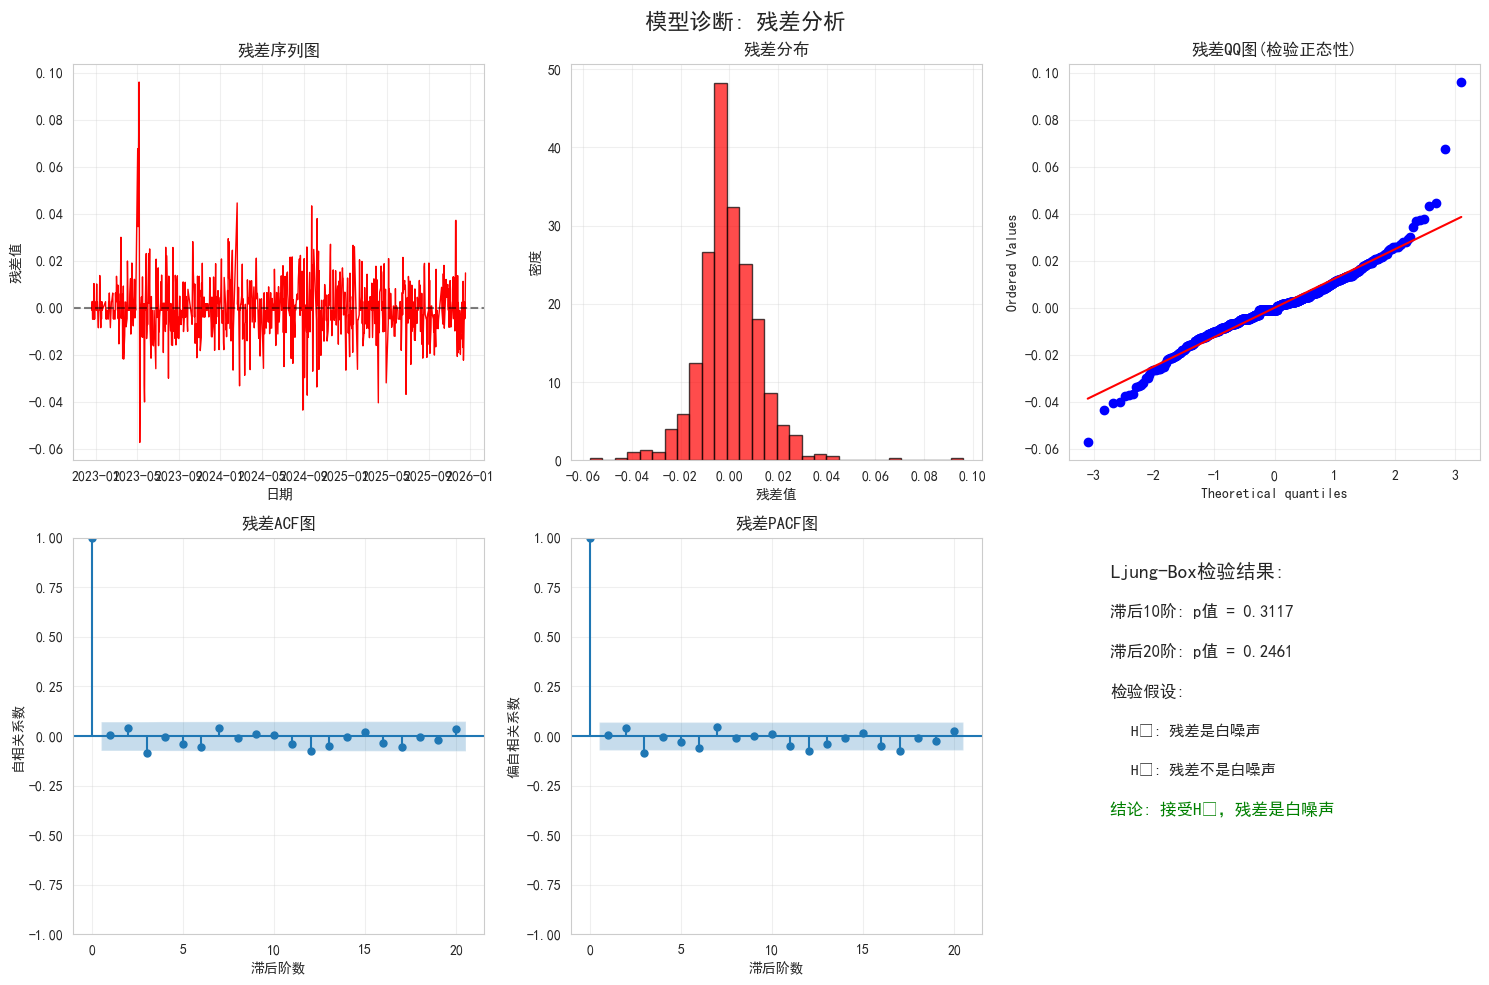


4.2 残差统计量:
  残差均值: 0.000005 (理论上应为0)
  残差标准差: 0.012819
  残差偏度: 0.594917 (越接近0越对称)
  残差峰度: 6.258948 (正态分布峰度为3)

4.3 Shapiro-Wilk正态性检验:
  统计量: 0.9433, p值: 0.0000
结论: 残差不服从正态分布 (p ≤ 0.05)

★ 步骤4总结: 模型诊断完成
模型通过诊断检验，可以用于预测


In [32]:
'''
ARIMA模型预测股票市场例子。
'''
# ========== 步骤4: 模型诊断 ==========
print("\n" + "="*60)
print("步骤4: 模型诊断")
print("="*60)

print("4.1 残差分析")
residuals = model_fit.resid

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('模型诊断: 残差分析', fontsize=16, fontweight='bold')

# 残差序列图
axes[0, 0].plot(residuals.index, residuals.values, linewidth=1, color='red')
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 0].set_title('残差序列图', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('日期')
axes[0, 0].set_ylabel('残差值')
axes[0, 0].grid(True, alpha=0.3)

# 残差直方图
axes[0, 1].hist(residuals, bins=30, color='red', edgecolor='black', alpha=0.7, density=True)
axes[0, 1].set_title('残差分布', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('残差值')
axes[0, 1].set_ylabel('密度')
axes[0, 1].grid(True, alpha=0.3)

# 残差QQ图
stats.probplot(residuals, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('残差QQ图(检验正态性)', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 残差ACF图
plot_acf(residuals, lags=20, ax=axes[1, 0], title='残差ACF图')
axes[1, 0].set_title('残差ACF图', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('滞后阶数')
axes[1, 0].set_ylabel('自相关系数')
axes[1, 0].grid(True, alpha=0.3)

# 残差PACF图
plot_pacf(residuals, lags=20, ax=axes[1, 1], title='残差PACF图')
axes[1, 1].set_title('残差PACF图', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('滞后阶数')
axes[1, 1].set_ylabel('偏自相关系数')
axes[1, 1].grid(True, alpha=0.3)

# Ljung-Box检验结果
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
axes[1, 2].axis('off')
axes[1, 2].text(0.1, 0.9, 'Ljung-Box检验结果:', fontsize=14, fontweight='bold')
axes[1, 2].text(0.1, 0.8, f'滞后10阶: p值 = {lb_test.iloc[0]["lb_pvalue"]:.4f}', fontsize=12)
axes[1, 2].text(0.1, 0.7, f'滞后20阶: p值 = {lb_test.iloc[1]["lb_pvalue"]:.4f}', fontsize=12)
axes[1, 2].text(0.1, 0.6, '检验假设:', fontsize=12, fontweight='bold')
axes[1, 2].text(0.15, 0.5, 'H₀: 残差是白噪声', fontsize=11)
axes[1, 2].text(0.15, 0.4, 'H₁: 残差不是白噪声', fontsize=11)

if lb_test.iloc[1]["lb_pvalue"] > 0.05:
    axes[1, 2].text(0.1, 0.3, '结论: 接受H₀，残差是白噪声', fontsize=12, color='green', fontweight='bold')
    print("  Ljung-Box检验: p值 > 0.05，残差是白噪声，模型通过检验")
else:
    axes[1, 2].text(0.1, 0.3, '结论: 拒绝H₀，残差不是白噪声', fontsize=12, color='red', fontweight='bold')
    print("  Ljung-Box检验: p值 ≤ 0.05，残差不是白噪声，模型可能需要改进")

plt.tight_layout()
plt.show()

# 计算残差统计量
print("\n4.2 残差统计量:")
print(f"  残差均值: {residuals.mean():.6f} (理论上应为0)")
print(f"  残差标准差: {residuals.std():.6f}")
print(f"  残差偏度: {residuals.skew():.6f} (越接近0越对称)")
print(f"  残差峰度: {residuals.kurtosis():.6f} (正态分布峰度为3)")

# 正态性检验
from scipy.stats import shapiro
shapiro_stat, shapiro_p = shapiro(residuals.dropna())
print(f"\n4.3 Shapiro-Wilk正态性检验:")
print(f"  统计量: {shapiro_stat:.4f}, p值: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("结论: 残差服从正态分布 (p > 0.05)")
else:
    print("结论: 残差不服从正态分布 (p ≤ 0.05)")

print("\n★ 步骤4总结: 模型诊断完成")
if lb_test.iloc[1]["lb_pvalue"] > 0.05:
    print("模型通过诊断检验，可以用于预测")
else:
    print("模型未完全通过诊断检验，预测结果需谨慎使用")



步骤5: 预测应用
预测未来5个交易日的对数收益率...

5.1 对数收益率预测结果:
  第1天: 0.001060 (95% CI: [-0.024039, 0.026160])
  第2天: 0.001060 (95% CI: [-0.024039, 0.026160])
  第3天: 0.001060 (95% CI: [-0.024039, 0.026160])
  第4天: 0.001060 (95% CI: [-0.024039, 0.026160])
  第5天: 0.001060 (95% CI: [-0.024039, 0.026160])

5.2 将收益率预测转换为价格预测...
  最近收盘价: 5.7000元

5.3 价格预测结果:
  第1天预测价格: 5.7060元
    95%置信区间: [5.5646, 5.8511]
  第2天预测价格: 5.7121元
    95%置信区间: [5.5705, 5.8573]
  第3天预测价格: 5.7182元
    95%置信区间: [5.5764, 5.8635]
  第4天预测价格: 5.7242元
    95%置信区间: [5.5823, 5.8697]
  第5天预测价格: 5.7303元
    95%置信区间: [5.5883, 5.8760]


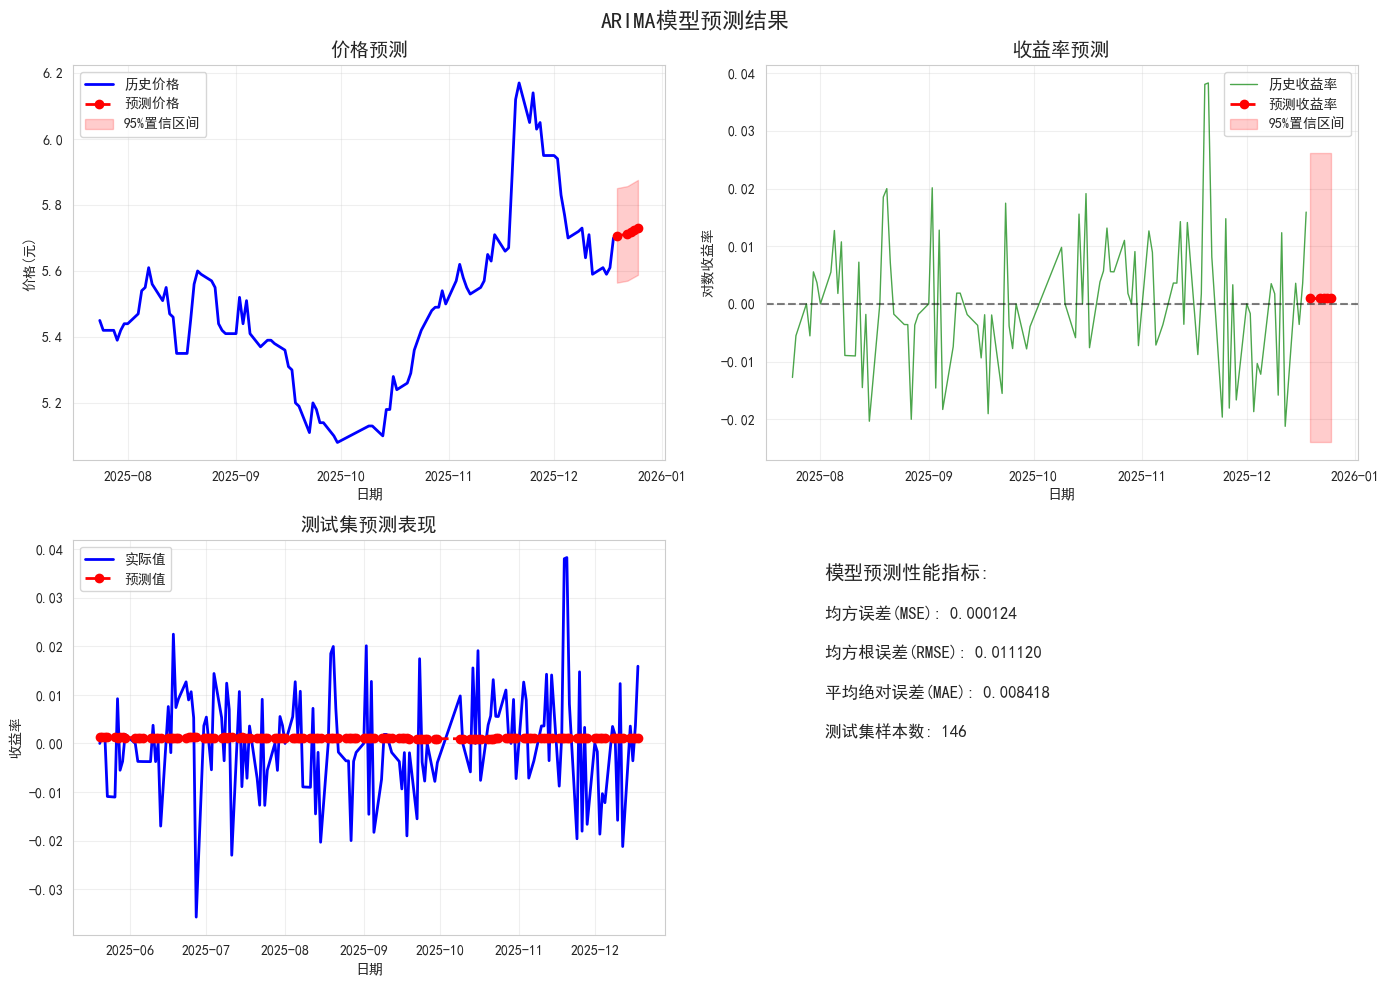

In [33]:
'''
ARIMA模型预测股票市场例子。
'''
# ========== 步骤5: 预测应用 ==========
print("\n" + "="*60)
print("步骤5: 预测应用")
print("="*60)

# 设置预测步数
forecast_steps = 5
print(f"预测未来{forecast_steps}个交易日的对数收益率...")

# 使用模型进行预测
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_conf_int = forecast_result.conf_int(alpha=0.05)  # 95%置信区间

print("\n5.1 对数收益率预测结果:")
for i, (date_idx, value) in enumerate(zip(forecast_mean.index, forecast_mean.values)):
    lower = forecast_conf_int.iloc[i, 0]
    upper = forecast_conf_int.iloc[i, 1]
    print(f"  第{i+1}天: {value:.6f} (95% CI: [{lower:.6f}, {upper:.6f}])")

# 将预测的对数收益率转换回价格
print("\n5.2 将收益率预测转换为价格预测...")

# 获取最近的价格
last_price = df['close'].iloc[-1]
print(f"  最近收盘价: {last_price:.4f}元")

# 创建价格预测
price_predictions = []
price_lower_bounds = []
price_upper_bounds = []

current_price = last_price
for i in range(forecast_steps):
    # 预测的对数收益率
    pred_return = forecast_mean.iloc[i]
    pred_lower = forecast_conf_int.iloc[i, 0]
    pred_upper = forecast_conf_int.iloc[i, 1]
    
    # 转换为价格
    pred_price = current_price * np.exp(pred_return)
    lower_price = current_price * np.exp(pred_lower)
    upper_price = current_price * np.exp(pred_upper)
    
    price_predictions.append(pred_price)
    price_lower_bounds.append(lower_price)
    price_upper_bounds.append(upper_price)
    
    # 更新当前价格（用于下一步预测）
    current_price = pred_price

print("\n5.3 价格预测结果:")
for i in range(forecast_steps):
    print(f"  第{i+1}天预测价格: {price_predictions[i]:.4f}元")
    print(f"    95%置信区间: [{price_lower_bounds[i]:.4f}, {price_upper_bounds[i]:.4f}]")

# 可视化预测结果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ARIMA模型预测结果', fontsize=16, fontweight='bold')

# 历史数据与预测对比
history_dates = df.index[-100:]  # 最近100个交易日
history_prices = df['close'].loc[history_dates]

# 创建预测日期（假设未来交易日连续）
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')

axes[0, 0].plot(history_dates, history_prices, 'b-', linewidth=2, label='历史价格')
axes[0, 0].plot(future_dates, price_predictions, 'r--', linewidth=2, marker='o', label='预测价格')
axes[0, 0].fill_between(future_dates, price_lower_bounds, price_upper_bounds, color='red', alpha=0.2, label='95%置信区间')
axes[0, 0].set_title('价格预测', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('日期')
axes[0, 0].set_ylabel('价格(元)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 收益率预测
history_returns = df['log_return'].dropna()[-100:]
axes[0, 1].plot(history_returns.index, history_returns.values, 'g-', linewidth=1, alpha=0.7, label='历史收益率')
axes[0, 1].plot(future_dates, forecast_mean.values, 'r--', linewidth=2, marker='o', label='预测收益率')
axes[0, 1].fill_between(future_dates, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], 
                        color='red', alpha=0.2, label='95%置信区间')
axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 1].set_title('收益率预测', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('日期')
axes[0, 1].set_ylabel('对数收益率')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 预测误差分析（如果有测试集的话）
if len(test_series) > 0:
    test_predictions = []
    test_actual = []
    
    # 使用滚动预测
    test_data = working_series.copy()
    train_size = len(train_series)
    
    for i in range(len(test_series)):
        # 使用截至当前的数据拟合模型
        history = test_data[:train_size + i]
        try:
            model_temp = ARIMA(history, order=(p, 0, q))
            model_temp_fit = model_temp.fit()
            # 预测下一步
            forecast_temp = model_temp_fit.forecast(steps=1)
            test_predictions.append(forecast_temp.iloc[0])
            test_actual.append(test_series.iloc[i])
        except:
            test_predictions.append(np.nan)
            test_actual.append(test_series.iloc[i])
    
    # 计算预测误差
    test_predictions = pd.Series(test_predictions, index=test_series.index)
    test_actual = pd.Series(test_actual, index=test_series.index)
    
    axes[1, 0].plot(test_actual.index, test_actual.values, 'b-', linewidth=2, label='实际值')
    axes[1, 0].plot(test_predictions.index, test_predictions.values, 'r--', linewidth=2, marker='o', label='预测值')
    axes[1, 0].set_title('测试集预测表现', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('日期')
    axes[1, 0].set_ylabel('收益率')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 计算并显示误差指标
    valid_idx = ~np.isnan(test_predictions)
    if valid_idx.sum() > 0:
        mse = np.mean((test_actual[valid_idx] - test_predictions[valid_idx])**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(test_actual[valid_idx] - test_predictions[valid_idx]))
        
        axes[1, 1].axis('off')
        axes[1, 1].text(0.1, 0.9, '模型预测性能指标:', fontsize=14, fontweight='bold')
        axes[1, 1].text(0.1, 0.8, f'均方误差(MSE): {mse:.6f}', fontsize=12)
        axes[1, 1].text(0.1, 0.7, f'均方根误差(RMSE): {rmse:.6f}', fontsize=12)
        axes[1, 1].text(0.1, 0.6, f'平均绝对误差(MAE): {mae:.6f}', fontsize=12)
        axes[1, 1].text(0.1, 0.5, f'测试集样本数: {valid_idx.sum()}', fontsize=12)
    else:
        axes[1, 1].axis('off')
        axes[1, 1].text(0.1, 0.9, '测试集预测结果不可用', fontsize=14, fontweight='bold')
else:
    axes[1, 0].axis('off')
    axes[1, 0].text(0.1, 0.5, '测试集数据不足，无法进行回测', fontsize=12)
    
    axes[1, 1].axis('off')
    axes[1, 1].text(0.1, 0.9, '交易策略建议:', fontsize=14, fontweight='bold')
    axes[1, 1].text(0.1, 0.8, '基于ARIMA模型的简单策略:', fontsize=12)
    axes[1, 1].text(0.15, 0.7, '1. 当预测收益率为正时考虑买入', fontsize=11)
    axes[1, 1].text(0.15, 0.6, '2. 当预测收益率为负时考虑卖出', fontsize=11)
    axes[1, 1].text(0.15, 0.5, '3. 结合置信区间管理风险:', fontsize=11)
    axes[1, 1].text(0.2, 0.4, '- 区间宽: 不确定性高, 减仓', fontsize=10)
    axes[1, 1].text(0.2, 0.3, '- 区间窄: 确定性高, 加仓', fontsize=10)

plt.tight_layout()
plt.show()


In [34]:
'''
ARIMA模型预测股票市场例子。
'''
# ========== 总结与策略建议 ==========
print("\n" + "="*60)
print("ARIMA建模总结与量化交易建议")
print("="*60)

print(f"\n1. 模型选择: ARIMA({p},{d},{q})")
print(f"   - 自回归阶数(p): {p}")
print(f"   - 差分阶数(d): {d}")
print(f"   - 移动平均阶数(q): {q}")

print(f"\n2. 模型质量评估:")
print(f"   - AIC信息准则: {model_fit.aic:.2f}")
print(f"   - 残差白噪声检验: {'通过' if lb_test.iloc[1]['lb_pvalue'] > 0.05 else '未通过'}")
print(f"   - 残差正态性检验: {'通过' if shapiro_p > 0.05 else '未通过'}")

print(f"\n3. 预测结果总结:")
print(f"   - 最近收盘价: {last_price:.4f}元")
print(f"   - {forecast_steps}天后预测价格: {price_predictions[-1]:.4f}元")
print(f"   - 预期收益率: {(price_predictions[-1]/last_price - 1)*100:.2f}%")

print(f"\n4. 量化交易策略建议:")
print("   a) 信号生成:")
print(f"      - 明日预测收益率: {forecast_mean.iloc[0]:.4%}")
print(f"      - 明日价格预测: {price_predictions[0]:.4f}元")

if forecast_mean.iloc[0] > 0:
    print("  生成买入信号 (预测收益率为正)")
else:
    print("   生成卖出信号 (预测收益率为负)")

print("\n   b) 风险管理:")
confidence_width = forecast_conf_int.iloc[0, 1] - forecast_conf_int.iloc[0, 0]
print(f"      - 预测不确定性: {confidence_width:.4f} (置信区间宽度)")
if confidence_width > 0.02:  # 假设阈值
    print("      → 不确定性较高，建议轻仓操作")
else:
    print("      → 不确定性较低，可以正常仓位操作")

print("\n   c) 模型更新建议:")
print("      - 每周或每月重新拟合模型")
print("      - 监控残差自相关性，如果变化需调整参数")
print("      - 结合其他模型(如GARCH)预测波动率")

print("\n5. ARIMA模型的局限性:")
print("   - 假设线性关系，无法捕捉市场非线性特征")
print("   - 对结构性变化(如政策突变)不敏感")
print("   - 长期预测误差会迅速累积")
print("   - 建议作为基准模型，与其他方法结合使用")


ARIMA建模总结与量化交易建议

1. 模型选择: ARIMA(0,0,0)
   - 自回归阶数(p): 0
   - 差分阶数(d): 0
   - 移动平均阶数(q): 0

2. 模型质量评估:
   - AIC信息准则: -4262.80
   - 残差白噪声检验: 通过
   - 残差正态性检验: 未通过

3. 预测结果总结:
   - 最近收盘价: 5.7000元
   - 5天后预测价格: 5.7303元
   - 预期收益率: 0.53%

4. 量化交易策略建议:
   a) 信号生成:
      - 明日预测收益率: 0.1060%
      - 明日价格预测: 5.7060元
  生成买入信号 (预测收益率为正)

   b) 风险管理:
      - 预测不确定性: 0.0502 (置信区间宽度)
      → 不确定性较高，建议轻仓操作

   c) 模型更新建议:
      - 每周或每月重新拟合模型
      - 监控残差自相关性，如果变化需调整参数
      - 结合其他模型(如GARCH)预测波动率

5. ARIMA模型的局限性:
   - 假设线性关系，无法捕捉市场非线性特征
   - 对结构性变化(如政策突变)不敏感
   - 长期预测误差会迅速累积
   - 建议作为基准模型，与其他方法结合使用


步骤1：数据获取与预处理
正在从Tushare获取中国银行(601988.SH)股票数据...
获取到数据共 1211 条
数据时间范围: 2020-12-24 00:00:00 到 2025-12-22 00:00:00

数据前5行:
  trade_date  open  close  high   low        vol
0 2020-12-24  2.33   2.34  2.34  2.33  674957.63
1 2020-12-25  2.34   2.34  2.34  2.33  651709.00
2 2020-12-28  2.34   2.34  2.34  2.33  748279.41
3 2020-12-29  2.34   2.34  2.34  2.33  819496.32
4 2020-12-30  2.34   2.34  2.34  2.33  796054.10


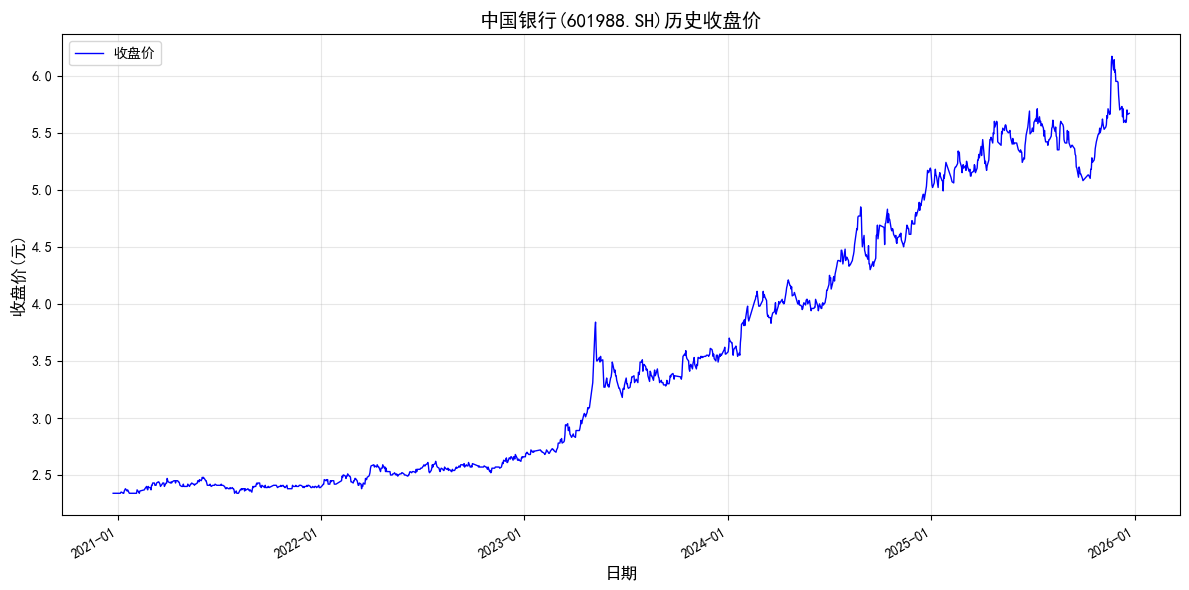


步骤2：特征工程 - 使用收盘价作为唯一特征
原始收盘价范围: 2.34 - 6.17
归一化后范围: 0.00 - 1.00

步骤3：创建RNN所需的时间序列数据集
序列长度(SEQ_LENGTH): 30
创建的数据集形状: X=(1181, 30, 1), y=(1181, 1)
示例 - 前30天的数据预测第31天的价格

训练集大小: 944 个样本
测试集大小: 237 个样本
训练张量形状: X_traintorch.Size([944, 30, 1]), y_traintorch.Size([944, 1])

步骤4：定义RNN神经网络模型
使用设备: cpu

模型结构:
SimpleRNN(
  (rnn): RNN(1, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

总参数数量: 7,801

步骤5：训练RNN模型
开始训练，共50个epoch...
Epoch [10/50], Loss: 0.000700
Epoch [20/50], Loss: 0.000496
Epoch [30/50], Loss: 0.000401
Epoch [40/50], Loss: 0.000374
Epoch [50/50], Loss: 0.000366


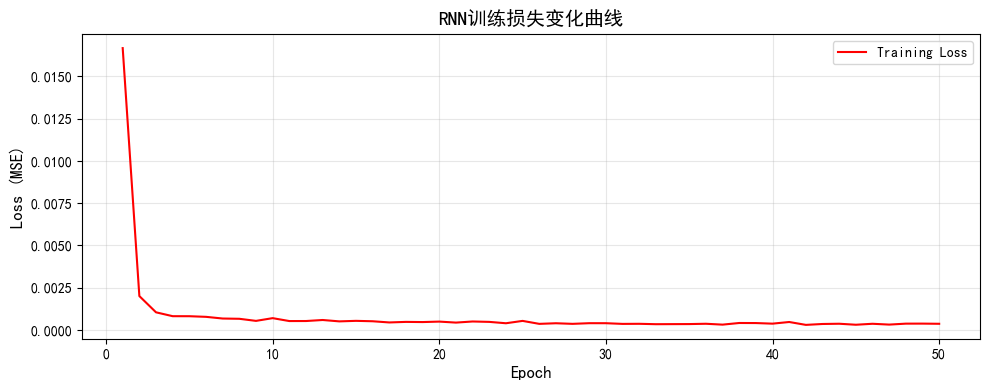


步骤6：模型预测与评估

步骤7：预测结果可视化


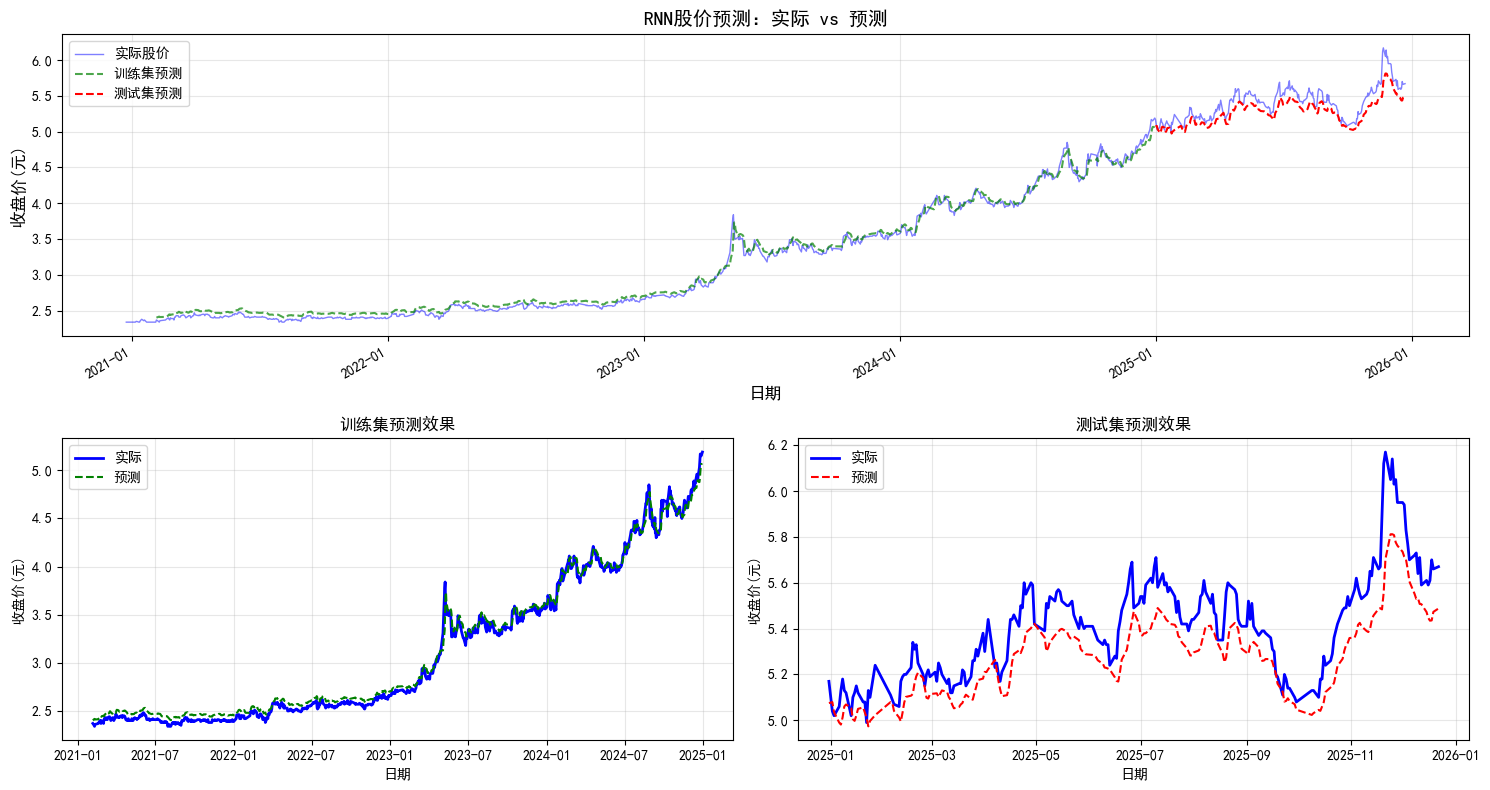


步骤8：使用模型预测未来一天的股价
最后交易日: 2025-12-22
最后收盘价: 5.67 元
预测下一个交易日价格: 5.49 元
预测变化: -0.18 元 (-3.21%)


In [1]:
'''
RNN股票预测：单特征场景
'''
# ========== 导入库 ==========
import tushare as ts
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.plotting import register_matplotlib_converters
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

register_matplotlib_converters()  # 解决pandas与matplotlib日期格式兼容问题

# 设置中文字体和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以保证结果可复现
np.random.seed(42)
torch.manual_seed(42)

# ========== 数据加载与预处理 ==========
print("="*50)
print("步骤1：数据获取与预处理")
print("="*50)

# 设置Tushare Token（需提前注册获取，官网：https://tushare.pro）
# 注意：这里使用的是示例token，您需要替换为您自己的token
# 如果没有token，可以使用 tushare 的旧版接口
ts.set_token('')  # 替换为你的实际token
pro = ts.pro_api()

# 设置时间范围
end_date = datetime.now().strftime('%Y%m%d')
start_date = (datetime.now() - timedelta(days=5*365)).strftime('%Y%m%d')

# 调用daily接口获取日线数据
print("正在从Tushare获取中国银行(601988.SH)股票数据...")
try:
    raw_df = ts.pro_bar(
        ts_code='601988.SH',  # 中国银行股票代码
        asset='E',            # E表示股票
        start_date=start_date,
        end_date=end_date,
        adj='qfq'             # 复权方式：qfq前复权
    )
except:
    # 如果pro_bar失败，尝试使用通用接口
    print("使用pro_bar失败，尝试使用通用接口...")
    raw_df = ts.get_hist_data('601988', start=start_date, end=end_date)
    raw_df = raw_df.reset_index()
    raw_df['trade_date'] = pd.to_datetime(raw_df['date'])
    raw_df['close'] = raw_df['close'].astype(float)

# 转换日期格式并排序
if 'trade_date' in raw_df.columns:
    raw_df['trade_date'] = pd.to_datetime(raw_df['trade_date'], format='%Y%m%d')
else:
    raw_df['trade_date'] = pd.to_datetime(raw_df['date'])
    
sorted_df = raw_df.sort_values('trade_date').reset_index(drop=True)

print(f"获取到数据共 {len(sorted_df)} 条")
print(f"数据时间范围: {sorted_df['trade_date'].min()} 到 {sorted_df['trade_date'].max()}")
print("\n数据前5行:")
print(sorted_df[['trade_date', 'open', 'close', 'high', 'low', 'volume']].head() if 'volume' in sorted_df.columns else 
      sorted_df[['trade_date', 'open', 'close', 'high', 'low', 'vol']].head())

# ========== 数据可视化（原始数据） ==========
plt.figure(figsize=(12, 6))
plt.plot(sorted_df['trade_date'], sorted_df['close'], label='收盘价', color='blue', linewidth=1)
plt.title('中国银行(601988.SH)历史收盘价', fontsize=14)
plt.xlabel('日期', fontsize=12)
plt.ylabel('收盘价(元)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ========== 特征工程：使用收盘价作为单特征 ==========
print("\n" + "="*50)
print("步骤2：特征工程 - 使用收盘价作为唯一特征")
print("="*50)

# 只使用收盘价作为特征
close_prices = sorted_df['close'].values.reshape(-1, 1)

# 数据归一化（对训练很重要）
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(close_prices)

print(f"原始收盘价范围: {close_prices.min():.2f} - {close_prices.max():.2f}")
print(f"归一化后范围: {scaled_prices.min():.2f} - {scaled_prices.max():.2f}")

# ========== 创建时间序列数据集 ==========
print("\n" + "="*50)
print("步骤3：创建RNN所需的时间序列数据集")
print("="*50)

def create_sequences(data, seq_length):
    """
    创建时间序列数据
    输入: [x1, x2, x3, ..., xn]
    输出: 
        X: [[x1, x2, ..., x_seq], [x2, x3, ..., x_seq+1], ...]
        y: [x_seq+1, x_seq+2, ...]
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# 设置时间窗口（用过去多少天的数据预测下一天）
SEQ_LENGTH = 30
X, y = create_sequences(scaled_prices, SEQ_LENGTH)

print(f"序列长度(SEQ_LENGTH): {SEQ_LENGTH}")
print(f"创建的数据集形状: X={X.shape}, y={y.shape}")
print(f"示例 - 前{SEQ_LENGTH}天的数据预测第{SEQ_LENGTH+1}天的价格")

# ========== 划分训练集和测试集 ==========
train_size = int(len(X) * 0.8)  # 80%训练，20%测试
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\n训练集大小: {len(X_train)} 个样本")
print(f"测试集大小: {len(X_test)} 个样本")

# 修正维度问题：X的形状应该是 (样本数, 序列长度, 特征数)
# 对于单特征，特征数为1
X_train = X_train.reshape(-1, SEQ_LENGTH, 1)
X_test = X_test.reshape(-1, SEQ_LENGTH, 1)

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print(f"训练张量形状: X_train{X_train_tensor.shape}, y_train{y_train_tensor.shape}")

# ========== 定义RNN模型 ==========
print("\n" + "="*50)
print("步骤4：定义RNN神经网络模型")
print("="*50)

class SimpleRNN(nn.Module):
    """
    简单的RNN模型用于股价预测
    结构: RNN层 → 全连接层
    """
    def __init__(self, input_size=1, hidden_size=50, output_size=1, num_layers=2):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # RNN层
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,  # 输入形状为(batch, seq, feature)
            dropout=0.2 if num_layers > 1 else 0  # 防止过拟合
        )
        
        # 全连接层
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x形状: (batch_size, seq_length, input_size)
        batch_size = x.size(0)
        
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        # RNN前向传播
        out, _ = self.rnn(x, h0)
        
        # 只取最后一个时间步的输出
        out = self.fc(out[:, -1, :])
        return out

# ========== 创建自定义数据集 ==========
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ========== 模型参数设置 ==========
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

model = SimpleRNN(
    input_size=1,      # 输入特征数（收盘价）
    hidden_size=50,    # RNN隐藏层大小
    output_size=1,     # 输出特征数（预测的收盘价）
    num_layers=2       # RNN层数
).to(device)

# 损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\n模型结构:")
print(model)
print(f"\n总参数数量: {sum(p.numel() for p in model.parameters()):,}")

# ========== 训练模型 ==========
print("\n" + "="*50)
print("步骤5：训练RNN模型")
print("="*50)

# 创建数据集和数据加载器
train_dataset = StockDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 训练参数
EPOCHS = 50
train_losses = []

print(f"开始训练，共{EPOCHS}个epoch...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # 前向传播
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        
        # 梯度裁剪（防止梯度爆炸）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 每10个epoch打印一次
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}')

# 绘制训练损失曲线
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', color='red')
plt.title('RNN训练损失变化曲线', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ========== 模型预测 ==========
print("\n" + "="*50)
print("步骤6：模型预测与评估")
print("="*50)

# 切换到评估模式
model.eval()

with torch.no_grad():
    # 训练集预测
    train_predictions = model(X_train_tensor.to(device))
    train_predictions = train_predictions.cpu().numpy()
    
    # 测试集预测
    test_predictions = model(X_test_tensor.to(device))
    test_predictions = test_predictions.cpu().numpy()

# 反归一化
train_predictions = scaler.inverse_transform(train_predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predictions = scaler.inverse_transform(test_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# ========== 计算评估指标 ==========
def calculate_metrics(actual, predicted):
    """计算各种评估指标"""
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    
    # 平均绝对百分比误差
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    return mse, rmse, mae, mape

# 训练集评估
train_mse, train_rmse, train_mae, train_mape = calculate_metrics(y_train_actual, train_predictions)

# 测试集评估
test_mse, test_rmse, test_mae, test_mape = calculate_metrics(y_test_actual, test_predictions)



# ========== 可视化预测结果 ==========
print("\n" + "="*50)
print("步骤7：预测结果可视化")
print("="*50)

# 准备日期数据用于绘图
train_dates = sorted_df['trade_date'][SEQ_LENGTH:SEQ_LENGTH+len(train_predictions)].values
test_dates = sorted_df['trade_date'][SEQ_LENGTH+len(train_predictions):SEQ_LENGTH+len(train_predictions)+len(test_predictions)].values

# 绘制整体预测图
plt.figure(figsize=(15, 8))

# 子图1：整体预测效果
plt.subplot(2, 2, (1, 2))
plt.plot(sorted_df['trade_date'], sorted_df['close'], label='实际股价', color='blue', linewidth=1, alpha=0.5)
plt.plot(train_dates, train_predictions, label='训练集预测', color='green', linewidth=1.5, linestyle='--', alpha=0.7)
plt.plot(test_dates, test_predictions, label='测试集预测', color='red', linewidth=1.5, linestyle='--')
plt.title('RNN股价预测：实际 vs 预测', fontsize=14)
plt.xlabel('日期', fontsize=12)
plt.ylabel('收盘价(元)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()

# 子图2：训练集详细视图
plt.subplot(2, 2, 3)
plt.plot(train_dates, y_train_actual, label='实际', color='blue', linewidth=2)
plt.plot(train_dates, train_predictions, label='预测', color='green', linewidth=1.5, linestyle='--')
plt.title('训练集预测效果', fontsize=12)
plt.xlabel('日期', fontsize=10)
plt.ylabel('收盘价(元)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend()

# 子图3：测试集详细视图
plt.subplot(2, 2, 4)
plt.plot(test_dates, y_test_actual, label='实际', color='blue', linewidth=2)
plt.plot(test_dates, test_predictions, label='预测', color='red', linewidth=1.5, linestyle='--')
plt.title('测试集预测效果', fontsize=12)
plt.xlabel('日期', fontsize=10)
plt.ylabel('收盘价(元)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ========== 预测未来一天 ==========
print("\n" + "="*50)
print("步骤8：使用模型预测未来一天的股价")
print("="*50)

# 使用最近SEQ_LENGTH天的数据预测下一天
last_sequence = scaled_prices[-SEQ_LENGTH:].reshape(1, SEQ_LENGTH, 1)
last_sequence_tensor = torch.FloatTensor(last_sequence).to(device)

model.eval()
with torch.no_grad():
    future_prediction = model(last_sequence_tensor)
    future_prediction = future_prediction.cpu().numpy()

# 反归一化
future_price = scaler.inverse_transform(future_prediction)[0][0]

last_date = sorted_df['trade_date'].iloc[-1]
last_price = sorted_df['close'].iloc[-1]

print(f"最后交易日: {last_date.strftime('%Y-%m-%d')}")
print(f"最后收盘价: {last_price:.2f} 元")
print(f"预测下一个交易日价格: {future_price:.2f} 元")
print(f"预测变化: {(future_price - last_price):.2f} 元 ({(future_price/last_price-1)*100:.2f}%)")



步骤1：数据获取与特征工程
正在从Tushare获取贵州茅台(600519.SH)股票数据...
获取到数据共 725 条
数据时间范围: 2022-12-26 00:00:00 到 2025-12-22 00:00:00

正在计算技术指标特征...
特征工程后数据量: 666 条
特征数量: 30 个技术指标 + 日期和收盘价

特征选择:
可用的特征 (21个): ['open', 'high', 'low', 'vol', 'returns', 'price_change', 'MA5', 'MA10', 'MA20', 'MA60', 'MA5_ratio', 'MA10_ratio', 'high_low_pct', 'close_open_pct', 'vol_ratio', 'volatility', 'RSI', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_width']
特征矩阵形状: (666, 21)
目标变量形状: (666, 1)


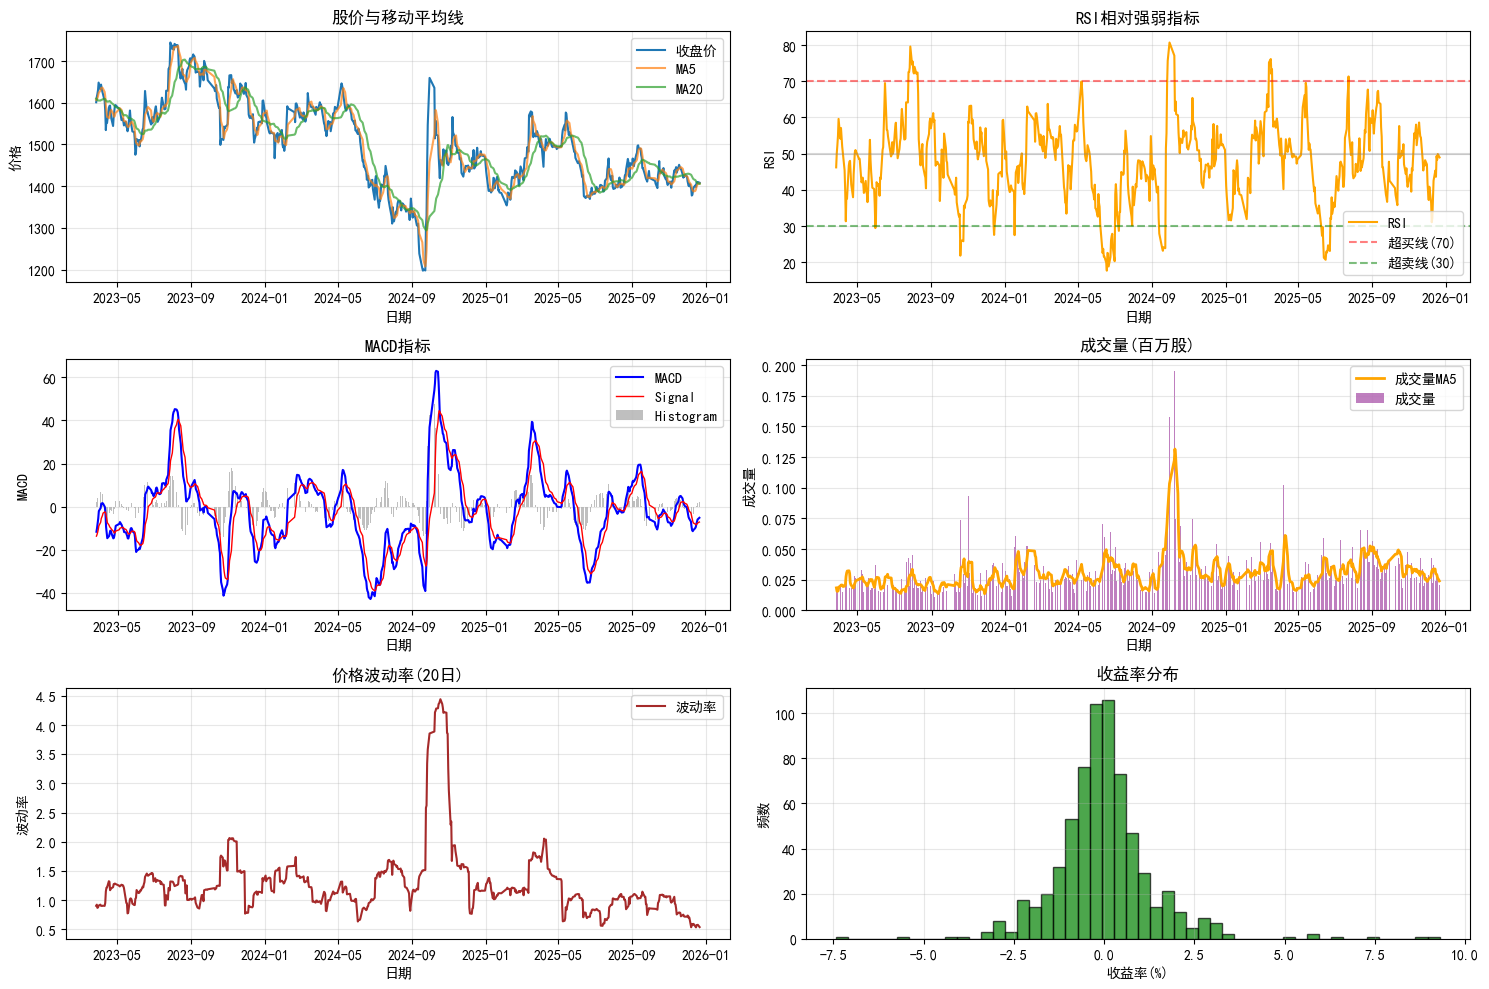


步骤2：数据标准化处理
特征标准化后范围: [-7.38, 11.26]
特征均值: 0.0000, 标准差: 1.0000
目标变量标准化后范围: [0.00, 1.00]

步骤3：创建多特征时间序列数据集
序列长度(SEQ_LENGTH): 20
特征数量: 21
创建的数据集形状: X=(646, 20, 21), y=(646, 1)
总样本数: 646

训练集大小: 516 个样本
测试集大小: 130 个样本
训练张量形状: X_traintorch.Size([516, 20, 21]), y_traintorch.Size([516, 1])

步骤4：定义多特征RNN模型
使用设备: cpu

模型结构:
MultiFeatureRNN(
  (rnn): RNN(21, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

输入特征数量: 21
总参数数量: 13,953

步骤5：训练多特征RNN模型
开始训练，共100个epoch...
Epoch [10/100], Train Loss: 0.139099, Val Loss: 0.018254, LR: 0.001000
Epoch [20/100], Train Loss: 0.033442, Val Loss: 0.006239, LR: 0.001000
Epoch [30/100], Train Loss: 0.013209, Val Loss: 0.003421, LR: 0.001000
Epoch [40/100], Train Loss: 0.008746, Val Loss: 0.003259, LR: 0.000500
Epoch [50/100], Train Loss: 0.006707, Val Loss: 0.004033, LR: 0.000250
Epoch [60/100], Train Loss: 0.006045, Val Loss: 0.003673, LR: 0.000125
Epoch [7

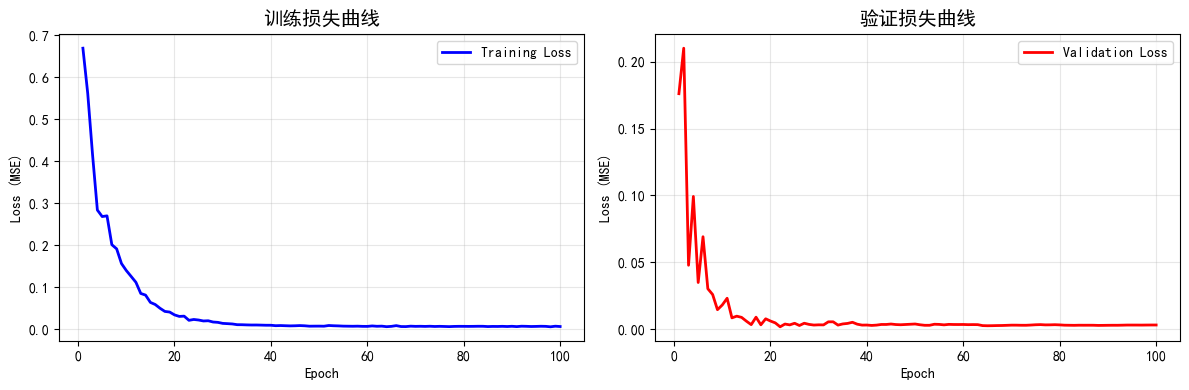


步骤6：模型预测与评估

模型性能评估:
指标              | 训练集                  | 测试集                 
----------------------------------------------------------------------
MSE             | 1156.110768          | 983.987023          
RMSE            | 34.001629            | 31.368567           
MAE             | 28.907582            | 26.190263           
MAPE(%)         | 1.91                 | 1.85                
R² Score        | 0.8902               | -0.2340             
方向准确率(%)        | 51.26                | 48.06               

步骤7：预测结果可视化


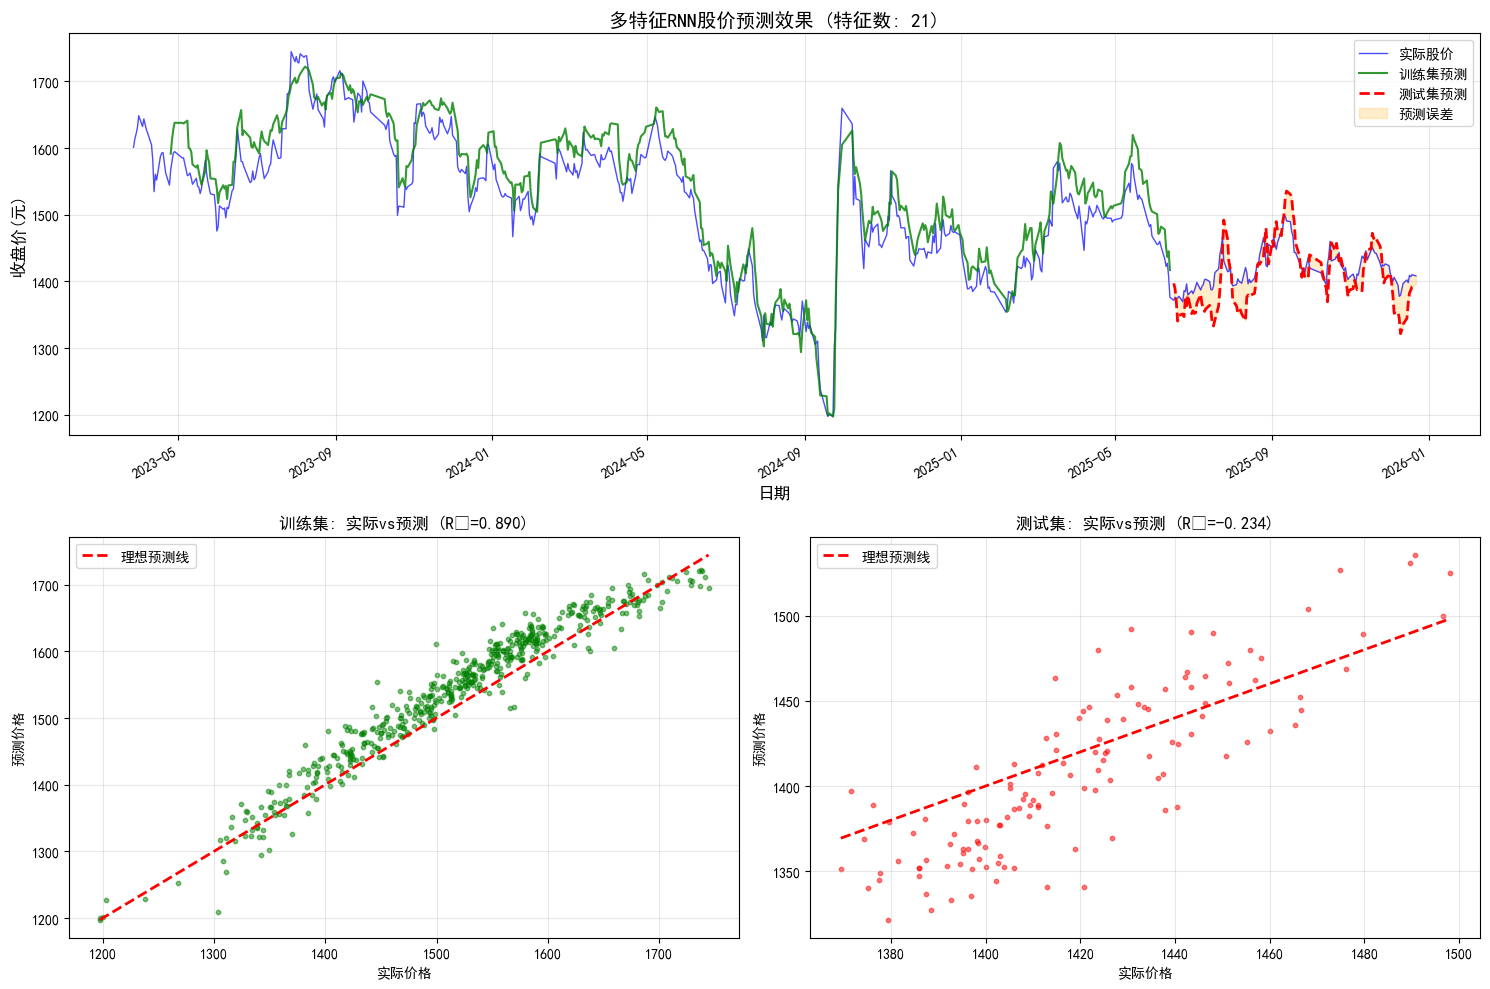


步骤8：特征重要性分析
特征重要性排名:
--------------------------------------------------
 1. MA20                   5.39%
 2. high                   5.34%
 3. price_change           5.24%
 4. volatility             5.01%
 5. vol                    5.00%
 6. MACD_signal            4.94%
 7. MA10_ratio             4.92%
 8. RSI                    4.87%
 9. open                   4.85%
10. MA10                   4.82%
11. high_low_pct           4.82%
12. BB_width               4.66%
13. MACD_hist              4.61%
14. returns                4.59%
15. close_open_pct         4.59%
16. MA5_ratio              4.54%
17. MA60                   4.54%
18. low                    4.45%
19. MA5                    4.43%
20. MACD                   4.37%
21. vol_ratio              4.03%


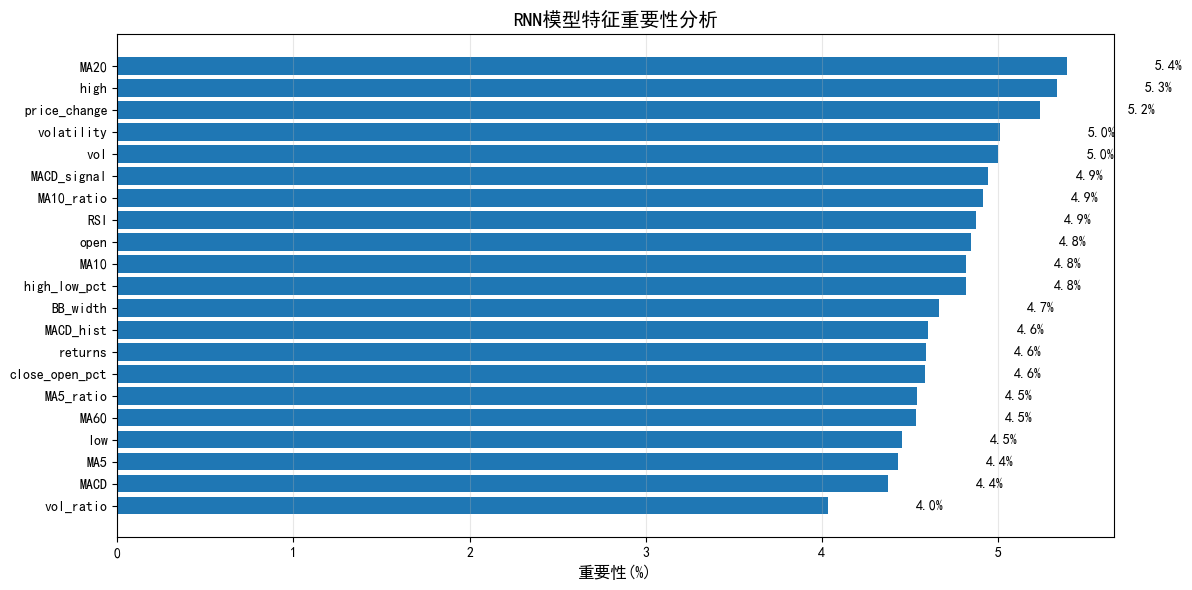


步骤9：使用模型预测未来一天的股价
最后交易日: 2025-12-22
最后收盘价: 1408.26 元
预测下一个交易日价格: 1385.39 元
预测变化: -22.87 元 (-1.62%)


In [2]:
'''
RNN股票预测：多特征场景
'''
# ========== 导入库 ==========
import tushare as ts
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.plotting import register_matplotlib_converters
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

register_matplotlib_converters()

# 设置随机种子以保证结果可复现
np.random.seed(42)
torch.manual_seed(42)

# ========== 数据加载与预处理 ==========
print("="*60)
print("步骤1：数据获取与特征工程")
print("="*60)

# 设置Tushare Token
ts.set_token('')
pro = ts.pro_api()

# 设置时间范围
end_date = datetime.now().strftime('%Y%m%d')
start_date = (datetime.now() - timedelta(days=3*365)).strftime('%Y%m%d')

print("正在从Tushare获取贵州茅台(600519.SH)股票数据...")
try:
    raw_df = ts.pro_bar(
        ts_code='600519.SH',
        asset='E',
        start_date=start_date,
        end_date=end_date,
        adj='qfq'
    )
except:
    print("使用pro_bar失败，尝试使用通用接口...")
    raw_df = ts.get_hist_data('600519', start=start_date[:8], end=end_date[:8])
    raw_df = raw_df.reset_index()
    raw_df['trade_date'] = pd.to_datetime(raw_df['date'])
    raw_df['close'] = raw_df['close'].astype(float)
    raw_df['open'] = raw_df['open'].astype(float)
    raw_df['high'] = raw_df['high'].astype(float)
    raw_df['low'] = raw_df['low'].astype(float)
    raw_df['vol'] = raw_df['volume'].astype(float) if 'volume' in raw_df.columns else raw_df['vol'].astype(float)

# 转换日期格式并排序
if 'trade_date' in raw_df.columns:
    raw_df['trade_date'] = pd.to_datetime(raw_df['trade_date'], format='%Y%m%d')
else:
    raw_df['trade_date'] = pd.to_datetime(raw_df['date'])
    
df = raw_df.sort_values('trade_date').reset_index(drop=True)

print(f"获取到数据共 {len(df)} 条")
print(f"数据时间范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")

# ========== 特征工程：计算技术指标 ==========
print("\n正在计算技术指标特征...")

# 确保数据列存在
if 'vol' not in df.columns and 'volume' in df.columns:
    df['vol'] = df['volume']

# 1. 基本价格特征
df['price_change'] = df['close'].diff()  # 价格变化
df['returns'] = df['close'].pct_change() * 100  # 收益率(%)

# 2. 移动平均线
df['MA5'] = df['close'].rolling(window=5).mean()
df['MA10'] = df['close'].rolling(window=10).mean()
df['MA20'] = df['close'].rolling(window=20).mean()
df['MA60'] = df['close'].rolling(window=60).mean()

# 3. 价格关系特征
df['MA5_ratio'] = df['close'] / df['MA5']
df['MA10_ratio'] = df['close'] / df['MA10']
df['high_low_pct'] = (df['high'] - df['low']) / df['close'] * 100
df['close_open_pct'] = (df['close'] - df['open']) / df['open'] * 100

# 4. 成交量特征
df['vol_MA5'] = df['vol'].rolling(window=5).mean()
df['vol_ratio'] = df['vol'] / df['vol_MA5']

# 5. 波动率特征
df['volatility'] = df['returns'].rolling(window=20).std()

# 6. RSI相对强弱指数
def calculate_rsi(prices, window=14):
    deltas = np.diff(prices)
    seed = deltas[:window]
    up = seed[seed >= 0].sum() / window
    down = -seed[seed < 0].sum() / window
    rs = up / down
    rsi = np.zeros_like(prices)
    rsi[:window] = 100. - 100. / (1. + rs)
    
    for i in range(window, len(prices)):
        delta = deltas[i-1]
        if delta > 0:
            upval = delta
            downval = 0.
        else:
            upval = 0.
            downval = -delta
            
        up = (up * (window-1) + upval) / window
        down = (down * (window-1) + downval) / window
        rs = up / down
        rsi[i] = 100. - 100. / (1. + rs)
    
    return rsi

df['RSI'] = calculate_rsi(df['close'].values)

# 7. MACD指标
exp1 = df['close'].ewm(span=12, adjust=False).mean()
exp2 = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist'] = df['MACD'] - df['MACD_signal']

# 8. 布林带
df['BB_middle'] = df['close'].rolling(window=20).mean()
bb_std = df['close'].rolling(window=20).std()
df['BB_upper'] = df['BB_middle'] + 2 * bb_std
df['BB_lower'] = df['BB_middle'] - 2 * bb_std
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / df['BB_middle']

# 删除NaN值
df_clean = df.dropna().reset_index(drop=True)

print(f"特征工程后数据量: {len(df_clean)} 条")
print(f"特征数量: {len(df_clean.columns) - 2} 个技术指标 + 日期和收盘价")

# ========== 选择特征和目标变量 ==========
print("\n特征选择:")
# 选择要使用的特征列（去除日期和不需要的列）
feature_columns = [
    'open', 'high', 'low', 'vol',  # 基本特征
    'returns', 'price_change',      # 变化特征
    'MA5', 'MA10', 'MA20', 'MA60',  # 移动平均
    'MA5_ratio', 'MA10_ratio',      # 价格关系
    'high_low_pct', 'close_open_pct',  # 价格波动
    'vol_ratio',                    # 成交量特征
    'volatility',                   # 波动率
    'RSI',                          # RSI
    'MACD', 'MACD_signal', 'MACD_hist',  # MACD
    'BB_width'                      # 布林带宽度
]

# 检查哪些特征在数据中
available_features = [col for col in feature_columns if col in df_clean.columns]
print(f"可用的特征 ({len(available_features)}个): {available_features}")

# 提取特征数据
features = df_clean[available_features].values
target = df_clean['close'].values.reshape(-1, 1)  # 目标：预测收盘价

print(f"特征矩阵形状: {features.shape}")
print(f"目标变量形状: {target.shape}")

# ========== 数据可视化：特征分析 ==========
plt.figure(figsize=(15, 10))

# 子图1：价格和移动平均线
plt.subplot(3, 2, 1)
plt.plot(df_clean['trade_date'], df_clean['close'], label='收盘价', linewidth=1.5)
plt.plot(df_clean['trade_date'], df_clean['MA5'], label='MA5', alpha=0.7)
plt.plot(df_clean['trade_date'], df_clean['MA20'], label='MA20', alpha=0.7)
plt.title('股价与移动平均线', fontsize=12)
plt.xlabel('日期')
plt.ylabel('价格')
plt.legend()
plt.grid(alpha=0.3)

# 子图2：RSI指标
plt.subplot(3, 2, 2)
plt.plot(df_clean['trade_date'], df_clean['RSI'], label='RSI', color='orange', linewidth=1.5)
plt.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='超买线(70)')
plt.axhline(y=30, color='g', linestyle='--', alpha=0.5, label='超卖线(30)')
plt.axhline(y=50, color='gray', linestyle='-', alpha=0.3)
plt.title('RSI相对强弱指标', fontsize=12)
plt.xlabel('日期')
plt.ylabel('RSI')
plt.legend()
plt.grid(alpha=0.3)

# 子图3：MACD指标
plt.subplot(3, 2, 3)
plt.plot(df_clean['trade_date'], df_clean['MACD'], label='MACD', color='blue', linewidth=1.5)
plt.plot(df_clean['trade_date'], df_clean['MACD_signal'], label='Signal', color='red', linewidth=1)
plt.bar(df_clean['trade_date'], df_clean['MACD_hist'], label='Histogram', color='gray', alpha=0.5)
plt.title('MACD指标', fontsize=12)
plt.xlabel('日期')
plt.ylabel('MACD')
plt.legend()
plt.grid(alpha=0.3)

# 子图4：成交量
plt.subplot(3, 2, 4)
plt.bar(df_clean['trade_date'], df_clean['vol'] / 1e6, color='purple', alpha=0.5, label='成交量')
plt.plot(df_clean['trade_date'], df_clean['vol_MA5'] / 1e6, color='orange', linewidth=2, label='成交量MA5')
plt.title('成交量(百万股)', fontsize=12)
plt.xlabel('日期')
plt.ylabel('成交量')
plt.legend()
plt.grid(alpha=0.3)

# 子图5：波动率
plt.subplot(3, 2, 5)
plt.plot(df_clean['trade_date'], df_clean['volatility'], label='波动率', color='brown', linewidth=1.5)
plt.title('价格波动率(20日)', fontsize=12)
plt.xlabel('日期')
plt.ylabel('波动率')
plt.legend()
plt.grid(alpha=0.3)

# 子图6：收益率分布
plt.subplot(3, 2, 6)
plt.hist(df_clean['returns'].dropna(), bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title('收益率分布', fontsize=12)
plt.xlabel('收益率(%)')
plt.ylabel('频数')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ========== 数据标准化 ==========
print("\n" + "="*60)
print("步骤2：数据标准化处理")
print("="*60)

# 分别标准化特征和目标变量
feature_scaler = StandardScaler()
target_scaler = MinMaxScaler(feature_range=(0, 1))

features_scaled = feature_scaler.fit_transform(features)
target_scaled = target_scaler.fit_transform(target)

print(f"特征标准化后范围: [{features_scaled.min():.2f}, {features_scaled.max():.2f}]")
print(f"特征均值: {features_scaled.mean():.4f}, 标准差: {features_scaled.std():.4f}")
print(f"目标变量标准化后范围: [{target_scaled.min():.2f}, {target_scaled.max():.2f}]")

# ========== 创建多特征时间序列数据集 ==========
print("\n" + "="*60)
print("步骤3：创建多特征时间序列数据集")
print("="*60)

def create_multivariate_sequences(features, target, seq_length):
    """
    创建多特征时间序列数据集
    输入: 
        features: (n_samples, n_features)
        target: (n_samples, 1)
    输出: 
        X: (n_samples-seq_length, seq_length, n_features)
        y: (n_samples-seq_length, 1)
    """
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i+seq_length, :])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 20  # 使用过去20天的数据
X, y = create_multivariate_sequences(features_scaled, target_scaled, SEQ_LENGTH)

print(f"序列长度(SEQ_LENGTH): {SEQ_LENGTH}")
print(f"特征数量: {features.shape[1]}")
print(f"创建的数据集形状: X={X.shape}, y={y.shape}")
print(f"总样本数: {len(X)}")

# ========== 划分训练集和测试集 ==========
train_size = int(len(X) * 0.8)  # 80%训练，20%测试
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\n训练集大小: {len(X_train)} 个样本")
print(f"测试集大小: {len(X_test)} 个样本")

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print(f"训练张量形状: X_train{X_train_tensor.shape}, y_train{y_train_tensor.shape}")

# ========== 定义多特征RNN模型 ==========
print("\n" + "="*60)
print("步骤4：定义多特征RNN模型")
print("="*60)

class MultiFeatureRNN(nn.Module):
    """
    多特征RNN模型用于股价预测
    结构: RNN层 → Dropout → 全连接层
    """
    def __init__(self, input_size, hidden_size=64, output_size=1, num_layers=2, dropout=0.3):
        super(MultiFeatureRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # RNN层
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            nonlinearity='tanh'  # 使用tanh激活函数
        )
        
        # Dropout层防止过拟合
        self.dropout = nn.Dropout(dropout)
        
        # 全连接层
        self.fc = nn.Linear(hidden_size, output_size)
        
        # 初始化权重
        self._init_weights()
        
    def _init_weights(self):
        for name, param in self.rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)
                
        nn.init.xavier_uniform_(self.fc.weight)
        self.fc.bias.data.fill_(0.01)
        
    def forward(self, x):
        # x形状: (batch_size, seq_length, input_size)
        batch_size = x.size(0)
        
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        # RNN前向传播
        out, _ = self.rnn(x, h0)
        
        # 应用dropout
        out = self.dropout(out[:, -1, :])  # 取最后一个时间步
        
        # 全连接层
        out = self.fc(out)
        return out

# 创建模型
input_size = X_train.shape[2]  # 特征数量
hidden_size = 64
output_size = 1
num_layers = 2

model = MultiFeatureRNN(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    num_layers=num_layers,
    dropout=0.3
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
model = model.to(device)

# 损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # L2正则化
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print("\n模型结构:")
print(model)
print(f"\n输入特征数量: {input_size}")
print(f"总参数数量: {sum(p.numel() for p in model.parameters()):,}")

# ========== 训练模型 ==========
print("\n" + "="*60)
print("步骤5：训练多特征RNN模型")
print("="*60)

# 创建数据集
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 训练参数
EPOCHS = 100
train_losses = []
val_losses = []

print(f"开始训练，共{EPOCHS}个epoch...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # 前向传播
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        
        # 梯度裁剪防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_test_tensor.to(device))
        val_loss = criterion(val_predictions, y_test_tensor.to(device)).item()
        val_losses.append(val_loss)
    
    # 调整学习率
    scheduler.step(val_loss)
    
    # 每10个epoch打印一次
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

# 绘制训练和验证损失曲线
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.title('训练损失曲线', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='red', linewidth=2)
plt.title('验证损失曲线', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ========== 模型预测与评估 ==========
print("\n" + "="*60)
print("步骤6：模型预测与评估")
print("="*60)

model.eval()

with torch.no_grad():
    # 训练集预测
    train_predictions_scaled = model(X_train_tensor.to(device)).cpu().numpy()
    
    # 测试集预测
    test_predictions_scaled = model(X_test_tensor.to(device)).cpu().numpy()

# 反归一化
train_predictions = target_scaler.inverse_transform(train_predictions_scaled)
y_train_actual = target_scaler.inverse_transform(y_train.reshape(-1, 1))
test_predictions = target_scaler.inverse_transform(test_predictions_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# ========== 计算评估指标 ==========
def calculate_all_metrics(actual, predicted):
    """计算多种评估指标"""
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    
    # 方向准确性（预测涨跌方向）
    direction_accuracy = np.mean((np.diff(actual.flatten()) * np.diff(predicted.flatten())) > 0) * 100
    
    return mse, rmse, mae, mape, r2, direction_accuracy

# 训练集评估
train_mse, train_rmse, train_mae, train_mape, train_r2, train_dir_acc = calculate_all_metrics(y_train_actual, train_predictions)

# 测试集评估
test_mse, test_rmse, test_mae, test_mape, test_r2, test_dir_acc = calculate_all_metrics(y_test_actual, test_predictions)

print("\n模型性能评估:")
print("="*70)
print(f"{'指标':<15} | {'训练集':<20} | {'测试集':<20}")
print("-"*70)
print(f"{'MSE':<15} | {train_mse:<20.6f} | {test_mse:<20.6f}")
print(f"{'RMSE':<15} | {train_rmse:<20.6f} | {test_rmse:<20.6f}")
print(f"{'MAE':<15} | {train_mae:<20.6f} | {test_mae:<20.6f}")
print(f"{'MAPE(%)':<15} | {train_mape:<20.2f} | {test_mape:<20.2f}")
print(f"{'R² Score':<15} | {train_r2:<20.4f} | {test_r2:<20.4f}")
print(f"{'方向准确率(%)':<15} | {train_dir_acc:<20.2f} | {test_dir_acc:<20.2f}")
print("="*70)

# ========== 可视化预测结果 ==========
print("\n" + "="*60)
print("步骤7：预测结果可视化")
print("="*60)

# 准备日期数据
train_dates = df_clean['trade_date'][SEQ_LENGTH:SEQ_LENGTH+len(train_predictions)].values
test_dates = df_clean['trade_date'][SEQ_LENGTH+len(train_predictions):SEQ_LENGTH+len(train_predictions)+len(test_predictions)].values

plt.figure(figsize=(15, 10))

# 子图1：整体预测效果
plt.subplot(2, 2, (1, 2))
plt.plot(df_clean['trade_date'], df_clean['close'], label='实际股价', color='blue', linewidth=1, alpha=0.7)
plt.plot(train_dates, train_predictions, label='训练集预测', color='green', linewidth=1.5, alpha=0.8)
plt.plot(test_dates, test_predictions, label='测试集预测', color='red', linewidth=2, linestyle='--')
plt.fill_between(test_dates.flatten(), 
                 y_test_actual.flatten(), 
                 test_predictions.flatten(), 
                 color='orange', alpha=0.2, label='预测误差')
plt.title(f'多特征RNN股价预测效果 (特征数: {input_size})', fontsize=14)
plt.xlabel('日期', fontsize=12)
plt.ylabel('收盘价(元)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.legend()

# 子图2：训练集详细视图
plt.subplot(2, 2, 3)
plt.scatter(y_train_actual, train_predictions, alpha=0.5, s=10, color='green')
plt.plot([y_train_actual.min(), y_train_actual.max()], 
         [y_train_actual.min(), y_train_actual.max()], 
         'r--', linewidth=2, label='理想预测线')
plt.xlabel('实际价格', fontsize=10)
plt.ylabel('预测价格', fontsize=10)
plt.title(f'训练集: 实际vs预测 (R²={train_r2:.3f})', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# 子图3：测试集详细视图
plt.subplot(2, 2, 4)
plt.scatter(y_test_actual, test_predictions, alpha=0.5, s=10, color='red')
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', linewidth=2, label='理想预测线')
plt.xlabel('实际价格', fontsize=10)
plt.ylabel('预测价格', fontsize=10)
plt.title(f'测试集: 实际vs预测 (R²={test_r2:.3f})', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ========== 特征重要性分析 ==========
print("\n" + "="*60)
print("步骤8：特征重要性分析")
print("="*60)

# 使用简单的权重分析
def analyze_feature_importance(model, feature_names):
    """分析特征重要性"""
    # 获取第一层RNN的权重
    rnn_weights = model.rnn.weight_ih_l0.detach().cpu().numpy()
    
    # 计算每个输入特征的权重绝对值之和
    importance = np.abs(rnn_weights).sum(axis=0)
    
    # 归一化
    importance = importance / importance.sum() * 100
    
    # 创建DataFrame
    importance_df = pd.DataFrame({
        '特征': feature_names,
        '重要性(%)': importance
    })
    
    # 按重要性排序
    importance_df = importance_df.sort_values('重要性(%)', ascending=False)
    
    return importance_df

# 分析特征重要性
importance_df = analyze_feature_importance(model, available_features)

print("特征重要性排名:")
print("-"*50)
for i, (_, row) in enumerate(importance_df.iterrows()):
    print(f"{i+1:2d}. {row['特征']:<20} {row['重要性(%)']:>6.2f}%")

# 可视化特征重要性
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(importance_df)), importance_df['重要性(%)'][::-1])
plt.yticks(range(len(importance_df)), importance_df['特征'][::-1])
plt.xlabel('重要性(%)', fontsize=12)
plt.title('RNN模型特征重要性分析', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, importance_df['重要性(%)'][::-1])):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', ha='left', va='center')

plt.tight_layout()
plt.show()

# ========== 预测未来一天 ==========
print("\n" + "="*60)
print("步骤9：使用模型预测未来一天的股价")
print("="*60)

# 使用最近SEQ_LENGTH天的数据预测下一天
last_features = features_scaled[-SEQ_LENGTH:].reshape(1, SEQ_LENGTH, -1)
last_features_tensor = torch.FloatTensor(last_features).to(device)

model.eval()
with torch.no_grad():
    future_prediction_scaled = model(last_features_tensor)
    future_prediction_scaled = future_prediction_scaled.cpu().numpy()

# 反归一化
future_price = target_scaler.inverse_transform(future_prediction_scaled)[0][0]

last_date = df_clean['trade_date'].iloc[-1]
last_price = df_clean['close'].iloc[-1]

print(f"最后交易日: {last_date.strftime('%Y-%m-%d')}")
print(f"最后收盘价: {last_price:.2f} 元")
print(f"预测下一个交易日价格: {future_price:.2f} 元")
print(f"预测变化: {(future_price - last_price):.2f} 元 ({(future_price/last_price-1)*100:.2f}%)")


In [ ]:
'''
LSTM股票预测：单特征场景
'''
# ========== 导入库 ==========
import tushare as ts
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# PyTorch相关库
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 设置中文字体和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
#sns.set_style("whitegrid")

# 设置随机种子以确保结果可重复
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 检查是否有GPU可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# ========== 数据加载与预处理 ==========

# 设置Tushare Token（注意：需要替换为您自己的token）
# 可以在https://tushare.pro注册获取免费token
ts.set_token('')  # 请替换为您的实际token
pro = ts.pro_api()

# 设置时间范围 - 获取5年的数据
end_date = datetime.now().strftime('%Y%m%d')
start_date = (datetime.now() - timedelta(days=5*365)).strftime('%Y%m%d')

print("正在从Tushare获取数据...")
print(f"时间范围: {start_date} 到 {end_date}")

# 获取中国银行股票数据
stock_code = '600519.SH'   # 000001.SZ 平安银行，601988.SH 中国银行，600519.SH 贵州茅台
stock_name = '中国银行'

raw_df = ts.pro_bar(
    ts_code=stock_code,
    asset='E',
    start_date=start_date,
    end_date=end_date,
    adj='qfq'  # 前复权
)

print(f"获取到 {len(raw_df)} 条数据")

# 数据检查
if raw_df.empty:
    raise ValueError("未获取到数据，请检查股票代码或网络连接")

# 转换日期格式并排序
raw_df['trade_date'] = pd.to_datetime(raw_df['trade_date'], format='%Y%m%d')
sorted_df = raw_df.sort_values('trade_date').reset_index(drop=True)

# 显示数据基本信息
print("\n=== 数据基本信息 ===")
print(f"数据时间范围: {sorted_df['trade_date'].min()} 到 {sorted_df['trade_date'].max()}")
print(f"数据列: {sorted_df.columns.tolist()}")
print(f"数据形状: {sorted_df.shape}")
print("\n前5行数据:")
print(sorted_df[['trade_date', 'open', 'high', 'low', 'close', 'vol']].head())

# ========== 数据可视化（原始数据）==========
import matplotlib.dates as mdates

plt.figure(figsize=(12, 8))

# 子图1: 收盘价走势
plt.subplot(2, 2, 1)
plt.plot(sorted_df['trade_date'], sorted_df['close'], linewidth=1, color='blue')
plt.title(f'{stock_name}收盘价走势')
plt.xlabel('日期')
plt.ylabel('收盘价(元)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

# 子图2: 成交量
plt.subplot(2, 2, 2)
plt.bar(sorted_df['trade_date'], sorted_df['vol'], width=1, color='gray', alpha=0.7)
plt.title(f'{stock_name}成交量')
plt.xlabel('日期')
plt.ylabel('成交量(手)')
plt.xticks(rotation=45)

# 子图3: 价格统计
plt.subplot(2, 2, 3)
price_stats = sorted_df[['open', 'high', 'low', 'close']]
sns.boxplot(data=price_stats)
plt.title('价格统计箱线图')
plt.ylabel('价格(元)')
plt.xticks(rotation=45)

# 子图4: 收益率分布
plt.subplot(2, 2, 4)
returns = sorted_df['close'].pct_change().dropna() * 100
plt.hist(returns, bins=50, edgecolor='black', alpha=0.7)
plt.title('日收益率分布')
plt.xlabel('收益率(%)')
plt.ylabel('频数')

plt.tight_layout()
plt.savefig('stock_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 数据准备（单特征：收盘价）==========
print("\n=== 准备LSTM模型数据 ===")

# 使用收盘价作为特征
data = sorted_df[['close']].values

# 数据标准化（LSTM对数据尺度敏感，需要归一化到0-1之间）
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"原始数据形状: {data.shape}")
print(f"标准化后数据形状: {scaled_data.shape}")

# ========== 创建时间序列数据集 ==========
def create_sequences(data, seq_length):
    """创建时间序列数据集"""
    sequences = []
    targets = []
    
    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length]
        target = data[i+seq_length]
        sequences.append(seq)
        targets.append(target)
    
    return np.array(sequences), np.array(targets)

# 设置时间步长（用过去多少天的数据预测下一天）
SEQ_LENGTH = 60
print(f"\n使用时间步长: {SEQ_LENGTH}天")

# 创建序列数据
X, y = create_sequences(scaled_data, SEQ_LENGTH)

print(f"特征数据X形状: {X.shape}")  # (样本数, 序列长度, 特征数)
print(f"目标数据y形状: {y.shape}")  # (样本数, 特征数)

# 划分训练集和测试集（80%训练，20%测试）
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\n训练集大小: {X_train.shape[0]} 个样本")
print(f"测试集大小: {X_test.shape[0]} 个样本")

# ========== 转换为PyTorch张量 ==========
# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建数据加载器
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n数据加载器配置:")
print(f"批次大小: {batch_size}")
print(f"训练批次数量: {len(train_loader)}")
print(f"测试批次数量: {len(test_loader)}")

# ========== 定义PyTorch LSTM模型 ==========
print("\n=== 构建PyTorch LSTM神经网络模型 ===")

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1, dropout_rate=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM层
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0
        )
        
        # Dropout层
        self.dropout = nn.Dropout(dropout_rate)
        
        # 全连接层
        self.fc1 = nn.Linear(hidden_size, 25)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(25, output_size)
        
    def forward(self, x):
        # LSTM前向传播
        lstm_out, _ = self.lstm(x)
        
        # 只取最后一个时间步的输出
        lstm_out = lstm_out[:, -1, :]
        
        # Dropout
        lstm_out = self.dropout(lstm_out)
        
        # 全连接层
        out = self.fc1(lstm_out)
        out = self.relu(out)
        out = self.fc2(out)
        
        return out

# 创建模型实例
model = LSTMModel(
    input_size=1,      # 单特征输入
    hidden_size=50,    # LSTM隐藏层大小
    num_layers=2,      # LSTM层数
    output_size=1,     # 输出维度
    dropout_rate=0.2   # Dropout率
).to(device)

# 显示模型结构
print("\n模型结构:")
print(model)
print(f"\n模型参数数量: {sum(p.numel() for p in model.parameters())}")

# ========== 定义损失函数和优化器 ==========
criterion = nn.MSELoss()  # 均方误差损失
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Adam优化器
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)  # 学习率调度器

print(f"\n优化器: {optimizer}")
print(f"损失函数: {criterion}")

# ========== 训练模型 ==========
print("\n=== 开始训练模型 ===")

# 训练参数
num_epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
patience = 10  # 早停耐心值

# 训练循环
for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        
        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
    
    # 计算平均训练损失
    train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # 验证阶段
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    
    # 计算平均验证损失
    val_loss = val_loss / len(test_loader.dataset)
    val_losses.append(val_loss)
    
    # 学习率调度
    scheduler.step(val_loss)
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
    
    # 打印训练进度
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.6f}, '
              f'Val Loss: {val_loss:.6f}, '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    # 早停检查
    if patience_counter >= patience:
        print(f'\n早停触发，在 {epoch+1} 轮停止训练')
        break

# 加载最佳模型
model.load_state_dict(torch.load('best_lstm_model.pth'))
print(f"\n最佳验证损失: {best_val_loss:.6f}")

# ========== 模型训练历史可视化 ==========
plt.figure(figsize=(12, 4))

# 损失函数曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='训练损失', linewidth=2)
plt.plot(val_losses, label='验证损失', linewidth=2)
plt.title('模型损失函数')
plt.xlabel('训练轮次')
plt.ylabel('损失值(MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# 损失函数对数坐标
plt.subplot(1, 2, 2)
plt.semilogy(train_losses, label='训练损失', linewidth=2)
plt.semilogy(val_losses, label='验证损失', linewidth=2)
plt.title('模型损失函数(对数坐标)')
plt.xlabel('训练轮次')
plt.ylabel('损失值(log MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pytorch_model_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 模型预测 ==========
print("\n=== 进行预测 ===")

# 在训练集上进行预测
model.eval()
with torch.no_grad():
    train_predict = model(X_train_tensor).cpu().numpy()
    test_predict = model(X_test_tensor).cpu().numpy()

# 反归一化，将预测值转换回原始价格
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train)
y_test_inv = scaler.inverse_transform(y_test)

# 计算评估指标
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
train_mae = mean_absolute_error(y_train_inv, train_predict)
test_mae = mean_absolute_error(y_test_inv, test_predict)

print(f"\n=== 模型性能评估 ===")
print(f"训练集 RMSE: {train_rmse:.4f}")
print(f"测试集 RMSE: {test_rmse:.4f}")
print(f"训练集 MAE: {train_mae:.4f}")
print(f"测试集 MAE: {test_mae:.4f}")
print(f"测试集平均绝对误差百分比: {(test_mae/np.mean(y_test_inv)*100):.2f}%")

# ========== 可视化预测结果 ==========

# 准备绘图数据
# 训练集预测
train_predict_plot = np.empty_like(scaled_data)
train_predict_plot[:, :] = np.nan
train_predict_plot[SEQ_LENGTH:SEQ_LENGTH+len(train_predict), :] = train_predict

# 测试集预测
test_predict_plot = np.empty_like(scaled_data)
test_predict_plot[:, :] = np.nan
test_predict_plot[SEQ_LENGTH+len(train_predict):SEQ_LENGTH+len(train_predict)+len(test_predict), :] = test_predict

# 原始数据
original_data = scaler.inverse_transform(scaled_data)

# 创建日期索引
dates = sorted_df['trade_date'].values[SEQ_LENGTH:]  # 从SEQ_LENGTH开始，因为前SEQ_LENGTH个数据点用于创建第一个序列

plt.figure(figsize=(15, 8))

# 绘制完整预测图
plt.plot(dates[:len(original_data)-SEQ_LENGTH], original_data[SEQ_LENGTH:], label='实际收盘价', color='blue', linewidth=1.5, alpha=0.7)
plt.plot(dates[:len(train_predict_plot)-SEQ_LENGTH], train_predict_plot[SEQ_LENGTH:], label='训练集预测', color='green', linewidth=2, alpha=0.8)
plt.plot(dates[:len(test_predict_plot)-SEQ_LENGTH], test_predict_plot[SEQ_LENGTH:], label='测试集预测', color='red', linewidth=2, alpha=0.9)

plt.title(f'{stock_name} - PyTorch LSTM股价预测结果 (单特征:收盘价)', fontsize=16, fontweight='bold')
plt.xlabel('日期', fontsize=12)
plt.ylabel('收盘价(元)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# 设置x轴格式
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('pytorch_lstm_prediction_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 显示测试集部分的详细预测 ==========
plt.figure(figsize=(15, 10))

# 测试集详细视图
test_start_idx = len(train_predict)
test_dates = dates[test_start_idx:test_start_idx + len(test_predict)]
test_actual = y_test_inv
test_pred = test_predict

plt.subplot(2, 1, 1)
plt.plot(test_dates, test_actual.flatten(), label='实际值', color='blue', linewidth=2, marker='o', markersize=4)
plt.plot(test_dates, test_pred.flatten(), label='预测值', color='red', linewidth=2, linestyle='--', marker='s', markersize=4)

plt.title(f'{stock_name} - 测试集详细预测对比', fontsize=14, fontweight='bold')
plt.xlabel('日期', fontsize=12)
plt.ylabel('收盘价(元)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# 添加预测误差线
for i, (actual, pred) in enumerate(zip(test_actual.flatten(), test_pred.flatten())):
    plt.plot([test_dates[i], test_dates[i]], [actual, pred], 'gray', linewidth=0.5, alpha=0.5)

plt.xticks(rotation=45)

# 预测误差图
plt.subplot(2, 1, 2)
errors = test_actual.flatten() - test_pred.flatten()
plt.bar(test_dates, errors, color='orange', alpha=0.7, edgecolor='black')
plt.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
plt.title('预测误差分布', fontsize=14, fontweight='bold')
plt.xlabel('日期', fontsize=12)
plt.ylabel('误差(实际-预测)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('pytorch_lstm_prediction_detail.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 未来预测 ==========
print("\n=== 进行未来预测 ===")

# 使用最后SEQ_LENGTH天的数据预测下一天
last_data = scaled_data[-SEQ_LENGTH:]  # 取最后60天的数据
last_data_tensor = torch.FloatTensor(last_data).unsqueeze(0).to(device)  # 调整为 [1, SEQ_LENGTH, 1]

# 预测下一天的收盘价
model.eval()
with torch.no_grad():
    future_pred_scaled = model(last_data_tensor).cpu().numpy()

future_pred = scaler.inverse_transform(future_pred_scaled)

print(f"\n基于最近{SEQ_LENGTH}天的数据预测结果:")
print(f"预测的下一天收盘价: {future_pred[0][0]:.2f} 元")

# 获取最近的实际价格
latest_date = sorted_df['trade_date'].iloc[-1]
latest_price = sorted_df['close'].iloc[-1]
print(f"最近交易日({latest_date.date()}): {latest_price:.2f} 元")
print(f"预测变化: {(future_pred[0][0]-latest_price):.2f} 元")

# ========== 保存模型和结果 ==========
print("\n=== 保存模型和结果 ===")

# 保存整个模型
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'seq_length': SEQ_LENGTH,
    'model_config': {
        'input_size': 1,
        'hidden_size': 50,
        'num_layers': 2,
        'output_size': 1,
        'dropout_rate': 0.2
    }
}, 'pytorch_lstm_model_complete.pth')

print("✓ 完整模型已保存为 'pytorch_lstm_model_complete.pth'")

# 保存预测结果到CSV
results_df = pd.DataFrame({
    'date': test_dates,
    'actual_price': test_actual.flatten(),
    'predicted_price': test_pred.flatten(),
    'error': errors
})

results_df.to_csv('pytorch_lstm_prediction_results.csv', index=False, encoding='utf-8-sig')
print("✓ 预测结果已保存为 'pytorch_lstm_prediction_results.csv'")

# 保存关键参数
with open('pytorch_model_parameters.txt', 'w', encoding='utf-8') as f:
    f.write(f"股票代码: {stock_code}\n")
    f.write(f"股票名称: {stock_name}\n")
    f.write(f"序列长度(SEQ_LENGTH): {SEQ_LENGTH}\n")
    f.write(f"设备: {device}\n")
    f.write(f"批次大小: {batch_size}\n")
    f.write(f"训练集样本数: {X_train.shape[0]}\n")
    f.write(f"测试集样本数: {X_test.shape[0]}\n")
    f.write(f"训练集RMSE: {train_rmse:.4f}\n")
    f.write(f"测试集RMSE: {test_rmse:.4f}\n")
    f.write(f"训练集MAE: {train_mae:.4f}\n")
    f.write(f"测试集MAE: {test_mae:.4f}\n")
    f.write(f"LSTM隐藏层大小: 50\n")
    f.write(f"LSTM层数: 2\n")
    f.write(f"Dropout率: 0.2\n")

print("✓ 模型参数已保存为 'pytorch_model_parameters.txt'")

# ========== 模型加载和预测示例 ==========
print("\n=== 模型加载和预测示例 ===")

def load_and_predict(model_path, new_data, seq_length=60):
    """加载模型并进行预测的示例函数"""
    # 加载模型
    checkpoint = torch.load(model_path, map_location=device)
    
    # 获取scaler
    scaler = checkpoint['scaler']
    seq_length = checkpoint['seq_length']
    model_config = checkpoint['model_config']
    
    # 创建新模型实例
    loaded_model = LSTMModel(**model_config).to(device)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()
    
    # 数据预处理
    scaled_data = scaler.transform(new_data)
    
    # 确保数据长度足够
    if len(scaled_data) < seq_length:
        raise ValueError(f"数据长度不足，需要至少{seq_length}个数据点")
    
    # 使用最后seq_length个数据点
    last_seq = scaled_data[-seq_length:]
    last_seq_tensor = torch.FloatTensor(last_seq).unsqueeze(0).to(device)
    
    # 预测
    with torch.no_grad():
        prediction_scaled = loaded_model(last_seq_tensor).cpu().numpy()
    
    # 反归一化
    prediction = scaler.inverse_transform(prediction_scaled)
    
    return prediction[0][0]

# 使用示例
print("模型加载和预测功能已实现")
print("调用 load_and_predict('pytorch_lstm_model_complete.pth', new_data) 进行预测")

print("\n=== PyTorch LSTM股价预测示例完成 ===")

In [ ]:
'''
LSTM股票预测：多特征场景
'''
# ========== 导入库 ==========
import tushare as ts
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch相关库
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 数据预处理
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 统计库
from scipy import stats
import matplotlib.dates as mdates

# 设置中文字体和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
#sns.set_style("whitegrid")

# 设置随机种子以确保结果可重复
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 检查是否有GPU可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# ========== 数据加载与预处理 ==========

# 设置Tushare Token
ts.set_token('')
pro = ts.pro_api()

# 设置时间范围
end_date = datetime.now().strftime('%Y%m%d')
start_date = (datetime.now() - timedelta(days=5*365)).strftime('%Y%m%d')

print("正在从Tushare获取数据...")
print(f"时间范围: {start_date} 到 {end_date}")

# 获取股票数据（使用贵州茅台作为示例）
stock_code = '600519.SH'  # 贵州茅台
stock_name = '贵州茅台'

raw_df = ts.pro_bar(
    ts_code=stock_code,
    asset='E',
    start_date=start_date,
    end_date=end_date,
    adj='qfq'
)

print(f"获取到 {len(raw_df)} 条数据")

if raw_df.empty:
    raise ValueError("未获取到数据，请检查股票代码或网络连接")

# 转换日期格式并排序
raw_df['trade_date'] = pd.to_datetime(raw_df['trade_date'], format='%Y%m%d')
df = raw_df.sort_values('trade_date').reset_index(drop=True)

# ========== 数据探索与特征工程 ==========
print("\n=== 数据探索与特征工程 ===")

# 显示基本信息
print(f"数据时间范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")
print(f"数据列: {df.columns.tolist()}")

# 1. 基础特征
print("\n1. 基础特征:")
print(df[['open', 'high', 'low', 'close', 'vol', 'amount']].describe())

# 2. 技术指标特征计算
print("\n2. 计算技术指标特征:")

# 移动平均线
df['MA5'] = df['close'].rolling(window=5).mean()
df['MA10'] = df['close'].rolling(window=10).mean()
df['MA20'] = df['close'].rolling(window=20).mean()

# 相对强弱指标 (RSI)
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI14'] = calculate_rsi(df['close'], 14)

# 布林带
df['BB_middle'] = df['close'].rolling(window=20).mean()
bb_std = df['close'].rolling(window=20).std()
df['BB_upper'] = df['BB_middle'] + 2 * bb_std
df['BB_lower'] = df['BB_middle'] - 2 * bb_std
df['BB_width'] = df['BB_upper'] - df['BB_lower']

# 成交量相关特征
df['volume_ma5'] = df['vol'].rolling(window=5).mean()
df['volume_ratio'] = df['vol'] / df['volume_ma5']

# 价格动量
df['price_change'] = df['close'].pct_change()
df['price_change_abs'] = df['price_change'].abs()

# 价格位置特征
df['high_low_ratio'] = (df['high'] - df['low']) / df['close']
df['close_position'] = (df['close'] - df['low']) / (df['high'] - df['low'])

# 波动率
df['volatility'] = df['close'].pct_change().rolling(window=20).std()

# 3. 滞后特征
print("\n3. 添加滞后特征:")

# 价格滞后特征
for lag in [1, 2, 3, 5]:
    df[f'close_lag_{lag}'] = df['close'].shift(lag)
    df[f'volume_lag_{lag}'] = df['vol'].shift(lag)

# 4. 目标变量 - 未来收益率
df['target'] = df['close'].shift(-1)  # 预测下一天的收盘价
df['target_return'] = (df['close'].shift(-1) - df['close']) / df['close']  # 未来一日收益率

# 删除NaN值
df_clean = df.dropna().reset_index(drop=True)

print(f"清洗后数据形状: {df_clean.shape}")
print(f"可用特征数量: {len(df_clean.columns) - 3}")  # 减去日期、原始收盘价、目标列

# ========== 特征选择与可视化 ==========
print("\n=== 特征选择与相关性分析 ===")

# 选择用于模型的特征
selected_features = [
    'open', 'high', 'low', 'close', 'vol', 'amount',
    'MA5', 'MA10', 'MA20', 'RSI14',
    'BB_middle', 'BB_upper', 'BB_lower', 'BB_width',
    'volume_ma5', 'volume_ratio',
    'price_change', 'high_low_ratio', 'close_position', 'volatility',
    'close_lag_1', 'close_lag_2', 'close_lag_3',
    'volume_lag_1', 'volume_lag_2'
]

print(f"选用的特征 ({len(selected_features)}个):")
for i, feat in enumerate(selected_features):
    print(f"{i+1:2d}. {feat}")

# 计算特征与目标的相关性
features_df = df_clean[selected_features]
target_series = df_clean['target']

# 计算相关性
correlations = {}
for feature in selected_features:
    correlation = np.corrcoef(features_df[feature], target_series)[0, 1]
    correlations[feature] = correlation

# 排序并显示相关性
sorted_correlations = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

print("\n特征与目标的相关性（绝对值排序）:")
for feature, corr in sorted_correlations[:10]:  # 显示前10个
    print(f"{feature:20s}: {corr:.4f}")

# ========== 特征相关性热力图 ==========
plt.figure(figsize=(16, 12))

# 计算相关性矩阵
corr_matrix = features_df.corr()

# 创建热力图
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title(f'{stock_name} - 特征相关性热力图', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 数据标准化 ==========
print("\n=== 数据标准化处理 ===")

# 分离特征和目标
features = df_clean[selected_features].values
target = df_clean['target'].values.reshape(-1, 1)

# 标准化特征
feature_scaler = StandardScaler()
features_scaled = feature_scaler.fit_transform(features)

# 标准化目标（收盘价）
target_scaler = StandardScaler()
target_scaled = target_scaler.fit_transform(target)

print(f"特征数据形状: {features_scaled.shape}")
print(f"目标数据形状: {target_scaled.shape}")
print(f"特征数量: {features_scaled.shape[1]}")

# ========== 创建序列数据集 ==========
def create_sequences_multi(features, target, seq_length):
    """为多特征LSTM创建序列数据集"""
    sequences = []
    targets = []
    
    for i in range(len(features) - seq_length):
        seq = features[i:i + seq_length]
        label = target[i + seq_length]
        sequences.append(seq)
        targets.append(label)
    
    return np.array(sequences), np.array(targets)

# 设置序列长度
SEQ_LENGTH = 60
print(f"\n序列长度: {SEQ_LENGTH}天")

# 创建序列
X, y = create_sequences_multi(features_scaled, target_scaled, SEQ_LENGTH)

print(f"序列数据X形状: {X.shape}")  # (样本数, 序列长度, 特征数)
print(f"目标数据y形状: {y.shape}")   # (样本数, 1)

# ========== 数据集划分 ==========
print("\n=== 数据集划分 ===")

# 划分训练集、验证集、测试集
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=False)

print(f"训练集: {X_train.shape[0]} 个样本 ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"验证集: {X_val.shape[0]} 个样本 ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"测试集: {X_test.shape[0]} 个样本 ({X_test.shape[0]/len(X)*100:.1f}%)")

# ========== 转换为PyTorch张量 ==========
print("\n=== 转换为PyTorch张量 ===")

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

print(f"训练张量形状: {X_train_tensor.shape}, {y_train_tensor.shape}")
print(f"验证张量形状: {X_val_tensor.shape}, {y_val_tensor.shape}")
print(f"测试张量形状: {X_test_tensor.shape}, {y_test_tensor.shape}")

# ========== 定义多特征LSTM模型 ==========
print("\n=== 构建多特征LSTM模型 ===")

class MultiFeatureLSTM(nn.Module):
    """多特征LSTM模型"""
    def __init__(self, input_size, hidden_size=100, num_layers=3, dropout_rate=0.3, output_size=1):
        super(MultiFeatureLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM层
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=False
        )
        
        # Dropout层
        self.dropout = nn.Dropout(dropout_rate)
        
        # 注意力机制（可选）
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        
        # 全连接层
        self.fc1 = nn.Linear(hidden_size, 50)
        self.fc2 = nn.Linear(50, 25)
        self.fc3 = nn.Linear(25, output_size)
        
        # 激活函数
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.01)
        
        # Batch Normalization
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.bn2 = nn.BatchNorm1d(50)
        self.bn3 = nn.BatchNorm1d(25)
        
    def forward(self, x, use_attention=True):
        batch_size = x.size(0)
        
        # LSTM前向传播
        lstm_out, (hidden, cell) = self.lstm(x)
        
        if use_attention:
            # 注意力机制
            attention_weights = self.attention(lstm_out)
            attention_weights = torch.softmax(attention_weights, dim=1)
            context_vector = torch.sum(attention_weights * lstm_out, dim=1)
        else:
            # 取最后一个时间步的输出
            context_vector = lstm_out[:, -1, :]
        
        # Batch Normalization和Dropout
        out = self.bn1(context_vector)
        out = self.dropout(out)
        
        # 全连接层
        out = self.fc1(out)
        out = self.bn2(out)
        out = self.leaky_relu(out)
        out = self.dropout(out)
        
        out = self.fc2(out)
        out = self.bn3(out)
        out = self.leaky_relu(out)
        out = self.dropout(out)
        
        out = self.fc3(out)
        
        return out

# 创建模型
input_size = X_train.shape[2]  # 特征数量
model = MultiFeatureLSTM(
    input_size=input_size,
    hidden_size=100,
    num_layers=3,
    dropout_rate=0.3,
    output_size=1
).to(device)

print(f"\n模型配置:")
print(f"输入特征数量: {input_size}")
print(f"LSTM隐藏层大小: 100")
print(f"LSTM层数: 3")
print(f"Dropout率: 0.3")

# 计算参数数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n模型参数:")
print(f"总参数数量: {total_params:,}")
print(f"可训练参数数量: {trainable_params:,}")

# ========== 定义损失函数和优化器 ==========
print("\n=== 定义训练参数 ===")

criterion = nn.MSELoss()  # 均方误差损失
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, verbose=True)

print(f"优化器: Adam (lr=0.001)")
print(f"损失函数: MSE")
print(f"学习率调度器: ReduceLROnPlateau")

# ========== 训练模型 ==========
print("\n=== 开始训练模型 ===")

# 训练参数
num_epochs = 100
batch_size = 32
patience = 15
best_val_loss = float('inf')
patience_counter = 0

# 创建数据加载器
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 记录训练历史
train_losses = []
val_losses = []
learning_rates = []

print(f"训练轮次: {num_epochs}")
print(f"批次大小: {batch_size}")
print(f"早停耐心值: {patience}")

# 训练循环
for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
    
    # 计算平均训练损失
    train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # 验证阶段
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    
    val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    # 学习率调度
    scheduler.step(val_loss)
    learning_rates.append(optimizer.param_groups[0]['lr'])
    
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_multi_feature_lstm.pth')
        patience_counter = 0
    else:
        patience_counter += 1
    
    # 打印训练进度
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}], '
              f'Train Loss: {train_loss:.6f}, '
              f'Val Loss: {val_loss:.6f}, '
              f'LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    # 早停检查
    if patience_counter >= patience:
        print(f'\n早停触发，在 {epoch+1} 轮停止训练')
        break

# 加载最佳模型
model.load_state_dict(torch.load('best_multi_feature_lstm.pth'))
print(f"\n最佳验证损失: {best_val_loss:.6f}")

# ========== 训练历史可视化 ==========
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 损失函数曲线
axes[0, 0].plot(train_losses, label='训练损失', linewidth=2)
axes[0, 0].plot(val_losses, label='验证损失', linewidth=2)
axes[0, 0].set_title('训练和验证损失')
axes[0, 0].set_xlabel('训练轮次')
axes[0, 0].set_ylabel('MSE损失')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 损失函数对数坐标
axes[0, 1].semilogy(train_losses, label='训练损失', linewidth=2)
axes[0, 1].semilogy(val_losses, label='验证损失', linewidth=2)
axes[0, 1].set_title('损失函数（对数坐标）')
axes[0, 1].set_xlabel('训练轮次')
axes[0, 1].set_ylabel('log(MSE)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 学习率变化
axes[1, 0].plot(learning_rates, linewidth=2, color='purple')
axes[1, 0].set_title('学习率变化')
axes[1, 0].set_xlabel('训练轮次')
axes[1, 0].set_ylabel('学习率')
axes[1, 0].grid(True, alpha=0.3)

# 损失差值
loss_diff = np.array(train_losses) - np.array(val_losses)
axes[1, 1].plot(loss_diff, linewidth=2, color='orange')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_title('训练损失与验证损失差值')
axes[1, 1].set_xlabel('训练轮次')
axes[1, 1].set_ylabel('损失差值')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multi_feature_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 模型评估 ==========
print("\n=== 模型评估 ===")

model.eval()

# 在测试集上进行预测
with torch.no_grad():
    test_predictions_scaled = model(X_test_tensor).cpu().numpy()


# 反标准化预测结果
test_predictions = target_scaler.inverse_transform(test_predictions_scaled)
test_actual = target_scaler.inverse_transform(y_test)  # y_test是numpy数组


# 计算评估指标
test_mse = mean_squared_error(test_actual, test_predictions)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_actual, test_predictions)
test_r2 = r2_score(test_actual, test_predictions)

# 计算百分比误差
percentage_errors = np.abs((test_actual - test_predictions) / test_actual) * 100
mean_percentage_error = np.mean(percentage_errors)
median_percentage_error = np.median(percentage_errors)

print(f"\n测试集性能指标:")
print(f"MSE:  {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R²分数: {test_r2:.4f}")
print(f"平均绝对百分比误差(MAPE): {mean_percentage_error:.2f}%")
print(f"中位数绝对百分比误差: {median_percentage_error:.2f}%")

# ========== 预测结果可视化 ==========
print("\n=== 预测结果可视化 ===")

# 准备绘图数据
test_dates = df_clean['trade_date'].values[-len(test_actual):]  # 测试集对应的日期

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 实际vs预测对比
axes[0, 0].plot(test_dates, test_actual, label='实际价格', color='blue', linewidth=2, alpha=0.8)
axes[0, 0].plot(test_dates, test_predictions, label='预测价格', color='red', linewidth=2, linestyle='--', alpha=0.8)
axes[0, 0].set_title(f'{stock_name} - 实际vs预测价格对比', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('日期')
axes[0, 0].set_ylabel('价格(元)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# 2. 预测误差分布
errors = test_actual - test_predictions
axes[0, 1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('预测误差分布', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('误差(实际-预测)')
axes[0, 1].set_ylabel('频数')
axes[0, 1].grid(True, alpha=0.3)

# 3. 预测vs实际散点图
axes[1, 0].scatter(test_actual, test_predictions, alpha=0.6, s=30)
axes[1, 0].plot([test_actual.min(), test_actual.max()], 
                [test_actual.min(), test_actual.max()], 
                'r--', linewidth=2)
axes[1, 0].set_title('预测vs实际散点图', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('实际价格')
axes[1, 0].set_ylabel('预测价格')
axes[1, 0].grid(True, alpha=0.3)

# 4. 累计误差
cumulative_error = np.cumsum(errors)
axes[1, 1].plot(test_dates, cumulative_error, linewidth=2, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title('累计预测误差', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('日期')
axes[1, 1].set_ylabel('累计误差')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('multi_feature_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 特征重要性分析 ==========
print("\n=== 特征重要性分析 ===")

# 使用梯度方法估计特征重要性
model.eval()
X_test_sample = X_test_tensor[:10]  # 使用小样本进行分析
X_test_sample.requires_grad = True

output = model(X_test_sample)
target = output.mean()
target.backward()

# 计算每个特征的梯度绝对值平均值
feature_importance = torch.abs(X_test_sample.grad).mean(dim=[0, 1]).cpu().numpy()

# 创建特征重要性DataFrame
importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n特征重要性排序（前15个）:")
for i, row in importance_df.head(15).iterrows():
    print(f"{row['feature']:20s}: {row['importance']:.6f}")

# 可视化特征重要性
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('特征重要性（梯度绝对值均值）')
plt.title(f'{stock_name} - 特征重要性排名', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== 未来预测 ==========
print("\n=== 未来预测 ===")

# 获取最近SEQ_LENGTH天的数据
recent_features = features_scaled[-SEQ_LENGTH:]
recent_tensor = torch.FloatTensor(recent_features).unsqueeze(0).to(device)

# 预测下一天
model.eval()
with torch.no_grad():
    future_pred_scaled = model(recent_tensor).cpu().numpy()

future_pred = target_scaler.inverse_transform(future_pred_scaled)

# 获取最近信息
latest_date = df_clean['trade_date'].iloc[-1]
latest_price = df_clean['close'].iloc[-1]
latest_target = df_clean['target'].iloc[-1]

print(f"\n预测信息:")
print(f"最近交易日: {latest_date.date()}")
print(f"当日收盘价: {latest_price:.2f} 元")
print(f"预测的下日收盘价: {future_pred[0][0]:.2f} 元")
print(f"预测涨跌: {(future_pred[0][0] - latest_price):.2f} 元")
print(f"预测涨跌幅: {((future_pred[0][0] - latest_price) / latest_price * 100):.2f}%")
print(f"实际下日收盘价: {latest_target:.2f} 元（用于验证）")

# ========== 模型保存 ==========
print("\n=== 保存模型和结果 ===")

# 保存完整模型
torch.save({
    'model_state_dict': model.state_dict(),
    'feature_scaler': feature_scaler,
    'target_scaler': target_scaler,
    'selected_features': selected_features,
    'seq_length': SEQ_LENGTH,
    'model_config': {
        'input_size': input_size,
        'hidden_size': 100,
        'num_layers': 3,
        'dropout_rate': 0.3,
        'output_size': 1
    },
    'performance': {
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'test_mape': mean_percentage_error
    }
}, 'multi_feature_lstm_complete.pth')

print("✓ 完整模型已保存为 'multi_feature_lstm_complete.pth'")

# 保存预测结果
results_df = pd.DataFrame({
    'date': test_dates,
    'actual_price': test_actual.flatten(),
    'predicted_price': test_predictions.flatten(),
    'error': errors.flatten(),
    'percentage_error': percentage_errors.flatten()
})

results_df.to_csv('multi_feature_prediction_results.csv', index=False, encoding='utf-8-sig')
print("✓ 预测结果已保存为 'multi_feature_prediction_results.csv'")

# 保存特征重要性
importance_df.to_csv('feature_importance.csv', index=False, encoding='utf-8-sig')
print("✓ 特征重要性已保存为 'feature_importance.csv'")

# 保存训练历史
history_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses,
    'learning_rate': learning_rates[:len(train_losses)]
})

history_df.to_csv('training_history.csv', index=False)
print("✓ 训练历史已保存为 'training_history.csv'")

print("\n=== PyTorch多特征LSTM股价预测示例完成 ===")
print(f"✓ 使用了 {len(selected_features)} 个特征")
print(f"✓ 序列长度: {SEQ_LENGTH} 天")
print(f"✓ 测试集R²分数: {test_r2:.4f}")
print(f"✓ 平均预测误差: {mean_percentage_error:.2f}%")